# Visualising Reskilling Scenarios

Clara Krämer, March 2025

### Notebook purpose:
1. Combines the individual simulation outputs to one dataframe.
2. Manipulates the output data for visualisations.
3. Plots all paper graphs.

### To do:
- (Understand the purpose of the boxplots at the bottom of the file and manage to run these)

#### 1. Load and prepare data

!! Important !! Select the specific environment/kernel for this notebook

In [27]:
# PythonProject/Simulating-Re-Skilling-Journeys/.venv/bin/python
# Python 3.11

# This environment runs with a newer numpy version to ensure compatibility with matplotlib and seaborn (required for line plots)

Load necessary requirements and patches

In [1]:
import os
import sys
import logging
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
from src.patches import seaborn_patch  # patch fix to avoid compatibility issues with updated script
import seaborn as sns

from src import utils, plotting_utils, stats_utils
from src import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm
import pickle
from scipy import stats

from src.modelling.reskilling_new_classification import ReskillingPathways
rp = ReskillingPathways()

→ Digital URIs: 21 | present in matrix: 21
→ Green   URIs: 570 | present in matrix: 570


##### Define model setting combinations

In [2]:
year = 2023
job_pools = ["shortage"]  # ["at_risk", "shortage"]
threshold = "viable-isco4d" # ["viable-low", "low", "perc", "emp"]
regional_constraints = ["regC", "no-regC"] # ["regC", "no-regC"]
reskilling_modes = [
    "reskill-digital",
    "reskill-green",
    "reskill-optimal",
    # "reskill-coreWeight",  # not ran
    "reskill-coreRanked"
]

# COEFFY normalization column per job_pool
coeff_pool_mapping = {
    "at_risk": "COEFFY_share_unviable_to_decarbonize",
    "shortage": "COEFFY_share_shortage"
}

# Rename job pool labels for nicer plotting
scenario_mapping = {
    "job_pool": {
        "at_risk": "AR",
        "shortage": "SH"
    }
}

# Toggle recomputing the model output
overwrite_model_results = True

##### Preprocess model outputs

In [3]:
# -----------------------------------------------------------------------
# Collect raw model output across all options (reg/no-reg) and scenarios
# -----------------------------------------------------------------------

# names and paths
folder_name = "reskilling_simulation"
# old name: "reskilling_final_thresh-viable-isco4d-v2"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_{year}"
output_dir = os.path.join(useful_paths.data_processed, "eulfs", "reskilling_model_results")
fname = "model_data_tidy_{}_{}".format(year, threshold) # add _new once model reran

if overwrite_model_results:
    # iterate across all options
    data_store = {}

    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            fpath = os.path.join(
                useful_paths.figure_dir,
                #"test",  # todo: delete after testing
                folder_name.format(threshold=threshold),
                fmt_string.format(
                    reskilling_mode=reskilling_mode,
                    regional_constraint=regional_constraint,
                    year=year
                ),
                "{}.pkl".format(
                    fmt_string.format(
                        reskilling_mode=reskilling_mode,
                        regional_constraint=regional_constraint,
                        year=year
                    )
                ),
            )
            data_store[
                (threshold, reskilling_mode, regional_constraint)
            ] = pd.read_pickle(fpath)

    # save to pickle
    fdir_out = os.path.join(
        useful_paths.figure_dir,
        #"test",
        folder_name.format(threshold=threshold),
        "model_data_store.pkl"
    )

    with open(fdir_out, "wb") as handle:
        pickle.dump(data_store, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # -----------------------------------------------------------------------
    # Build up aggregated data cube of modelling results across all scenarios
    # -----------------------------------------------------------------------
    data_tidy = []
    for model_version in tqdm(list(data_store.keys())):
        # threshold - reskilling - regional constraint
        sub_dict = data_store[model_version]

        for job_pool in job_pools:
            # pool - country - DATA
            df_pool = pd.concat(list(sub_dict[job_pool].values()))

            # only keep select variables
            df_pool_sel = df_pool

            # add metadata of model run
            df_pool_sel = df_pool_sel.assign(
                job_pool=job_pool,
                viability_threshold=model_version[0],
                reskilling_mode=model_version[1],
                regional_constraint=model_version[2]
            )

            # append
            data_tidy.append(df_pool_sel)

    df_tidy = pd.concat(data_tidy)
    df_tidy = df_tidy.reset_index()

    # -----------------------------------------------------------------------
    # Clean data set
    # -----------------------------------------------------------------------
    # rename job pools
    df_tidy = df_tidy.replace(scenario_mapping)

    # make sure entries for countries with missing earnings data_transitions are coded as NaNs
    #earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE", "GR", "IS", "UK"] #old
    earnings_data_missing = ['IT', 'NL', 'DE', 'HU', 'AT', 'RO', 'PL', 'ES', 'LT', 'CY', 'BE', 'CZ', 'HR', 'IS', 'LV']
    df_tidy.loc[
        df_tidy["COUNTRYW"].isin(earnings_data_missing),
        "earnings_delta_closest_switch_sum_mio",
    ] = np.nan

    # add nace labels
    df_tidy = pd.merge(df_tidy, rp.nace_labels, on="NACE2_1D", how="left")

    # Save concatenated results data
    utils.save_df_to_files(
        df=df_tidy,
        output_dir=output_dir,
        fname_no_ext=fname
    )
else:
    # read results from existing model run
    df_tidy = pd.read_pickle(os.path.join(output_dir, fname + ".pkl"))

100%|██████████| 8/8 [00:00<00:00, 25.14it/s]


Further prepare data

In [4]:
#HARDCODED TO ONE TRANSITION FLOW

# only keep reskilling steps 0 to 20?
cols2keep = ~df_tidy.columns.str.contains("step_31") #step_31 for shortage
df_tidy = df_tidy.loc[:, cols2keep]

In [5]:
# reduce data to core sectors
df_tidy = df_tidy.loc[df_tidy["paper_selection"]]

In [6]:
iso_missing_earnings = ['IT', 'NL', 'DE', 'HU', 'AT', 'RO','PL', 'ES', 'LT', 'CY', 'BE','CZ', 'HR', 'IS', 'LV']

In [7]:
import re
import numpy as np
import pandas as pd

# Assumes:
#   df_tidy  : wide, group-aggregated output from simulate/simulate_regional
#   iso_missing_earnings : list of ISO codes with no earnings (ok if empty/missing)

try:
    iso_missing_earnings
except NameError:
    iso_missing_earnings = []

# ── Explicit regex pickers (no ambiguity) ──────────────────────────────────────
def pick_cols_regex(df, pattern):
    rx = re.compile(pattern)
    return [c for c in df.columns if rx.match(c)]

# transitions (counts)
transitions_cols   = pick_cols_regex(df_tidy, r"^n_viable_transitions_step_\d+$")

# per-observation totals (€)
earnings_cols_abs  = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_sum_step_\d+$")

# per-worker (€, unweighted)
earnings_cols_rel  = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_step_\d+$")

# per-worker % change
pct_cols           = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_pct_step_\d+$")

# optional HV variants
earnings_cols_abs_hv = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_sum_hv_step_\d+$")
earnings_cols_rel_hv = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_hv_step_\d+$")
pct_cols_hv          = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_hv_pct_step_\d+$")

# id_vars = all columns minus value_vars
value_vars_all = set(transitions_cols) | set(earnings_cols_abs) | set(earnings_cols_rel) | set(pct_cols) \
                 | set(earnings_cols_abs_hv) | set(earnings_cols_rel_hv) | set(pct_cols_hv)
index_cols = [c for c in df_tidy.columns if c not in value_vars_all]

# helper to extract the trailing integer step
def extract_step_from_name(s):
    return s.str.extract(r"_step_(\d+)$", expand=False).astype(int)

# ── Mask earnings for countries without earnings ───────────────────────────────
if len(earnings_cols_abs):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_abs] = np.nan
if len(earnings_cols_rel):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel] = np.nan
if len(earnings_cols_abs_hv):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_abs_hv] = np.nan
if len(earnings_cols_rel_hv):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel_hv] = np.nan
# pct series are implied by annual_earnings, so they’ll already be NaN where needed

# ── Melt to long ───────────────────────────────────────────────────────────────
# transitions
df_tidy_long_transitions = df_tidy.melt(
    id_vars=index_cols, value_vars=transitions_cols,
    var_name="colname", value_name="n_transitions"
)
df_tidy_long_transitions["reskilling_step"] = extract_step_from_name(df_tidy_long_transitions["colname"])
df_tidy_long_transitions = df_tidy_long_transitions.drop(columns=["colname"])

# totals (€)
df_tidy_long_earnings_abs = df_tidy.melt(
    id_vars=index_cols, value_vars=earnings_cols_abs,
    var_name="colname", value_name="earnings_delta_abs"
)
df_tidy_long_earnings_abs["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_abs["colname"])
df_tidy_long_earnings_abs = df_tidy_long_earnings_abs.drop(columns=["colname"])

# per-worker (€, unweighted)
df_tidy_long_earnings_rel = df_tidy.melt(
    id_vars=index_cols, value_vars=earnings_cols_rel,
    var_name="colname", value_name="earnings_delta_rel"
)
df_tidy_long_earnings_rel["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_rel["colname"])
df_tidy_long_earnings_rel = df_tidy_long_earnings_rel.drop(columns=["colname"])

# per-worker % change (optional)
if len(pct_cols):
    df_tidy_long_earnings_pct = df_tidy.melt(
        id_vars=index_cols, value_vars=pct_cols,
        var_name="colname", value_name="earnings_delta_pct"
    )
    df_tidy_long_earnings_pct["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_pct["colname"])
    df_tidy_long_earnings_pct = df_tidy_long_earnings_pct.drop(columns=["colname"])
else:
    df_tidy_long_earnings_pct = None

# optional helpers
def melt_optional(df, cols, value_name):
    if not len(cols):
        return None
    out = df.melt(id_vars=index_cols, value_vars=cols, var_name="colname", value_name=value_name)
    out["reskilling_step"] = extract_step_from_name(out["colname"])
    return out.drop(columns=["colname"])

df_tidy_long_earnings_abs_hv = melt_optional(df_tidy, earnings_cols_abs_hv, "earnings_delta_abs_hv")
df_tidy_long_earnings_rel_hv = melt_optional(df_tidy, earnings_cols_rel_hv, "earnings_delta_rel_hv")
df_tidy_long_earnings_pct_hv = melt_optional(df_tidy, pct_cols_hv,          "earnings_delta_pct_hv")

# ── Merge per-worker & totals ─────────────────────────────────────────────────
keys_merge = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode","reskilling_step"]

earnings_abs = df_tidy_long_earnings_abs[keys_merge + ["earnings_delta_abs"]]
earnings_rel = df_tidy_long_earnings_rel[keys_merge + ["earnings_delta_rel"]]

df_tidy_long_earnings_merged = pd.merge(
    earnings_abs, earnings_rel, on=keys_merge, how="left", validate="m:1"
)

if df_tidy_long_earnings_pct is not None:
    df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
        df_tidy_long_earnings_pct[keys_merge + ["earnings_delta_pct"]],
        on=keys_merge, how="left", validate="m:1"
    )

# ── Scales ────────────────────────────────────────────────────────────────────
df_tidy_long_earnings_merged["earnings_delta_abs_mio"] = df_tidy_long_earnings_merged["earnings_delta_abs"] / 1e6
df_tidy_long_earnings_merged["earnings_delta_abs_bio"] = df_tidy_long_earnings_merged["earnings_delta_abs"] / 1e9
df_tidy_long_earnings_merged["earnings_delta_rel_mio"] = df_tidy_long_earnings_merged.get("earnings_delta_rel") / 1e6
df_tidy_long_earnings_merged["earnings_delta_rel_bio"] = df_tidy_long_earnings_merged.get("earnings_delta_rel") / 1e9

# ── Weighted per-worker (ties exactly to totals) ──────────────────────────────
cand_weight_cols = [c for c in [
    "COEFFY_share_unviable_to_decarbonize",
    "COEFFY_share_high_carbon",
    "COEFFY_share_shortage",
] if c in df_tidy.columns]

if not cand_weight_cols:
    raise ValueError("No COEFFY_share_* weight columns found in df_tidy.")

if len(cand_weight_cols) > 1:
    jp_vals = set(df_tidy.get("job_pool", pd.Series(dtype=object)).dropna().unique().tolist())
    if {"AR","at_risk"} & jp_vals:
        weight_col = "COEFFY_share_unviable_to_decarbonize"
    elif {"HC","high_carbon"} & jp_vals:
        weight_col = "COEFFY_share_high_carbon"
    elif {"SH","shortage"} & jp_vals:
        weight_col = "COEFFY_share_shortage"
    else:
        totals = {c: df_tidy[c].sum(skipna=True) for c in cand_weight_cols}
        weight_col = max(totals, key=totals.get)
else:
    weight_col = cand_weight_cols[0]

keys_no_step = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode"]
wide_weights = (
    df_tidy[keys_no_step + [weight_col]]
    .drop_duplicates()
    .rename(columns={weight_col: "weight_sum"})
)

df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
    wide_weights, on=keys_no_step, how="left", validate="m:1"
)

df_tidy_long_earnings_merged["earnings_delta_rel_w"] = (
    df_tidy_long_earnings_merged["earnings_delta_abs"] / df_tidy_long_earnings_merged["weight_sum"]
)
z = df_tidy_long_earnings_merged["weight_sum"] == 0
df_tidy_long_earnings_merged.loc[z, "earnings_delta_rel_w"] = np.nan

df_tidy_long_earnings_merged["earnings_delta_rel_w_mio"] = df_tidy_long_earnings_merged["earnings_delta_rel_w"] / 1e6
df_tidy_long_earnings_merged["earnings_delta_rel_w_bio"] = df_tidy_long_earnings_merged["earnings_delta_rel_w"] / 1e9

# (Optional) add HV series into the same tidy frame
for opt_df, val in [(df_tidy_long_earnings_abs_hv, "earnings_delta_abs_hv"),
                    (df_tidy_long_earnings_rel_hv, "earnings_delta_rel_hv"),
                    (df_tidy_long_earnings_pct_hv, "earnings_delta_pct_hv")]:
    if opt_df is not None:
        df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
            opt_df[keys_merge + [val]], on=keys_merge, how="left", validate="m:1"
        )

print("Detected columns:")
print("  transitions :", len(transitions_cols))
print("  totals(€)   :", len(earnings_cols_abs))
print("  per-worker  :", len(earnings_cols_rel))
print("  pct         :", len(pct_cols))
print("  HV totals   :", len(earnings_cols_abs_hv))
print("  HV per-w    :", len(earnings_cols_rel_hv))
print("  HV pct      :", len(pct_cols_hv))
print("Data prep complete. Result:", df_tidy_long_earnings_merged.shape)

Detected columns:
  transitions : 31
  totals(€)   : 31
  per-worker  : 31
  pct         : 31
  HV totals   : 0
  HV per-w    : 0
  HV pct      : 0
Data prep complete. Result: (312356, 18)


Data inspection

In [8]:
earnings_rel.describe()

,reskilling_step,earnings_delta_rel
count,"312,356.00","93,135.00"
mean,15.00,"1,755.41"
std,8.94,"6,412.31"
min,0.00,"-21,216.37"
25%,7.00,0.00
50%,15.00,0.00
75%,23.00,0.00
max,30.00,"72,639.53"


In [9]:
import numpy as np
import pandas as pd

def _fmt(x):
    try:
        return f"{x:,.2f}"
    except Exception:
        return x

print("Detected job_pool values:", sorted(df_tidy_long_earnings_merged["job_pool"].dropna().unique().tolist()))
steps_abs = sorted(df_tidy_long_earnings_merged["reskilling_step"].dropna().unique().tolist())
print("Steps present:", steps_abs[:10], "...", steps_abs[-3:] if len(steps_abs)>10 else steps_abs)

print("\nEarnings (totals, €) — describe():")
print(df_tidy_long_earnings_merged["earnings_delta_abs"].describe().apply(_fmt))

if "earnings_delta_rel" in df_tidy_long_earnings_merged:
    print("\nEarnings (per-worker, unweighted €, ‘typical worker’) — describe():")
    print(df_tidy_long_earnings_merged["earnings_delta_rel"].describe().apply(_fmt))

print("\nEarnings (per-worker, weighted by headcount €, ties to totals) — describe():")
print(df_tidy_long_earnings_merged["earnings_delta_rel_w"].describe().apply(_fmt))

# Masking check (only among missing-earnings countries)
if 'iso_missing_earnings' in globals() and len(iso_missing_earnings) > 0:
    mask_c = df_tidy_long_earnings_merged["COUNTRYW"].isin(iso_missing_earnings)
    na_abs_share = df_tidy_long_earnings_merged.loc[mask_c, "earnings_delta_abs"].isna().mean()
    if "earnings_delta_rel" in df_tidy_long_earnings_merged:
        na_rel_share = df_tidy_long_earnings_merged.loc[mask_c, "earnings_delta_rel"].isna().mean()
    else:
        na_rel_share = float("nan")
    print(f"\nMasking among missing-earnings countries: abs NaN share={na_abs_share:.3f}, rel NaN share={na_rel_share:.3f}")

# Reconciliation: totals ≡ weighted_mean × weight_sum
chk = df_tidy_long_earnings_merged.dropna(subset=["earnings_delta_abs","earnings_delta_rel_w","weight_sum"]).copy()
chk.loc[:, "recon_err"] = chk["earnings_delta_abs"] - chk["earnings_delta_rel_w"]*chk["weight_sum"]
print("\nReconciliation (totals - weighted_mean × weight_sum):")
if len(chk):
    print("  MAE =", _fmt(chk["recon_err"].abs().mean()),
          "| max|err| =", _fmt(chk["recon_err"].abs().max()))
    print("\nWorst 5 reconciliation rows:")
    cols_show = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool",
                 "reskilling_mode","reskilling_step",
                 "earnings_delta_abs","weight_sum","earnings_delta_rel_w","recon_err"]
    display(chk.loc[chk["recon_err"].abs().sort_values(ascending=False).index[:5], cols_show])
else:
    print("  (no rows to check)")

# Weighted vs unweighted per-worker gap (only if unweighted exists)
if "earnings_delta_rel" in df_tidy_long_earnings_merged:
    diff_pw = df_tidy_long_earnings_merged.dropna(subset=["earnings_delta_rel","earnings_delta_rel_w"]).copy()
    diff_pw.loc[:, "per_worker_gap"] = diff_pw["earnings_delta_rel_w"] - diff_pw["earnings_delta_rel"]
    print("\n(per-worker weighted - per-worker unweighted) — describe():")
    print(diff_pw["per_worker_gap"].describe().apply(_fmt))
    print("\nWorst 5 gaps (headcount weighting vs typical-worker):")
    cols_show2 = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool",
                  "reskilling_mode","reskilling_step",
                  "earnings_delta_rel","earnings_delta_rel_w","weight_sum","per_worker_gap"]
    display(diff_pw.loc[diff_pw["per_worker_gap"].abs().sort_values(ascending=False).index[:5], cols_show2])
else:
    print("\n(no unweighted per-worker series present — this is fine if you prefer to use weighted only)")

panel = (
    df_tidy_long_earnings_merged
    .groupby(["job_pool","regional_constraint","reskilling_mode","reskilling_step"], dropna=False)
    .agg(
        totals_eur      = ("earnings_delta_abs", "sum"),
        mean_unweighted = ("earnings_delta_rel", "mean") if "earnings_delta_rel" in df_tidy_long_earnings_merged else ("earnings_delta_rel_w", lambda x: np.nan),
        mean_weighted   = ("earnings_delta_rel_w", "mean"),
        weight_sum      = ("weight_sum", "sum")
    )
    .reset_index()
)
print("\nStep-level panel summary (first 10 rows):")
display(panel.head(10))

print("Debug checks completed.")


Detected job_pool values: ['SH']
Steps present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [28, 29, 30]

Earnings (totals, €) — describe():
count           93,248.00
mean         8,033,148.85
std         50,409,944.98
min        -11,660,026.63
25%                  0.00
50%                  0.00
75%                  0.00
max      1,726,538,844.04
Name: earnings_delta_abs, dtype: object

Earnings (per-worker, unweighted €, ‘typical worker’) — describe():
count     93,135.00
mean       1,755.41
std        6,412.31
min      -21,216.37
25%            0.00
50%            0.00
75%            0.00
max       72,639.53
Name: earnings_delta_rel, dtype: object

Earnings (per-worker, weighted by headcount €, ties to totals) — describe():
count    93,124.00
mean         56.09
std         205.46
min        -684.40
25%           0.00
50%           0.00
75%           0.00
max       2,343.21
Name: earnings_delta_rel_w, dtype: object

Masking among missing-earnings countries: abs NaN share=1.000, rel NaN share=1

,COUNTRYW,NUTS_ID,NACE2_1D_label,regional_constraint,job_pool,reskilling_mode,reskilling_step,earnings_delta_abs,weight_sum,earnings_delta_rel_w,recon_err
299110,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,29,"941,950,324.58","1,343,881.00",700.92,-0.00
297856,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,regC,SH,reskill-optimal,29,"941,950,324.58","1,343,881.00",700.92,-0.00
289034,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,28,"941,950,324.58","1,343,881.00",700.92,-0.00
309186,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,30,"941,950,324.58","1,343,881.00",700.92,-0.00
287780,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,regC,SH,reskill-optimal,28,"941,950,324.58","1,343,881.00",700.92,-0.00



(per-worker weighted - per-worker unweighted) — describe():
count     93,011.00
mean      -1,701.03
std        6,210.99
min      -70,296.32
25%            0.00
50%            0.00
75%            0.00
max       20,531.97
Name: per_worker_gap, dtype: object

Worst 5 gaps (headcount weighting vs typical-worker):


,COUNTRYW,NUTS_ID,NACE2_1D_label,regional_constraint,job_pool,reskilling_mode,reskilling_step,earnings_delta_rel,earnings_delta_rel_w,weight_sum,per_worker_gap
312056,LU,LU00,"Agriculture, Forestry and Fishing",no-regC,SH,reskill-coreRanked,30,"72,639.53","2,343.21","2,418.00","-70,296.32"
312059,LU,LU00,Construction,no-regC,SH,reskill-coreRanked,30,"63,727.96","1,791.44","3,224.00","-61,936.52"
312060,LU,LU00,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-coreRanked,30,"61,048.67","1,930.62","73,408.00","-59,118.05"
311197,CH,CH03,"Agriculture, Forestry and Fishing",no-regC,SH,reskill-coreRanked,30,"60,734.87","1,959.19","5,208.00","-58,775.68"
309958,CH,CH03,"Agriculture, Forestry and Fishing",regC,SH,reskill-coreRanked,30,"60,734.87","1,959.19","5,208.00","-58,775.68"



Step-level panel summary (first 10 rows):


,job_pool,regional_constraint,reskilling_mode,reskilling_step,totals_eur,mean_unweighted,mean_weighted,weight_sum
0,SH,no-regC,reskill-coreRanked,0,0.00,0.00,0.00,"240,639,515.00"
1,SH,no-regC,reskill-coreRanked,1,0.00,0.00,0.00,"240,639,515.00"
2,SH,no-regC,reskill-coreRanked,2,0.00,0.00,0.00,"240,639,515.00"
3,SH,no-regC,reskill-coreRanked,3,0.00,0.00,0.00,"240,639,515.00"
4,SH,no-regC,reskill-coreRanked,4,0.00,0.00,0.00,"240,639,515.00"
5,SH,no-regC,reskill-coreRanked,5,0.00,0.00,0.00,"240,639,515.00"
6,SH,no-regC,reskill-coreRanked,6,0.00,0.00,0.00,"240,639,515.00"
7,SH,no-regC,reskill-coreRanked,7,0.00,0.00,0.00,"240,639,515.00"
8,SH,no-regC,reskill-coreRanked,8,0.00,0.00,0.00,"240,639,515.00"
9,SH,no-regC,reskill-coreRanked,9,0.00,0.00,0.00,"240,639,515.00"


Debug checks completed.


#### 2. Plotting parameters for aggregated reskilling journeys and income changes

In [10]:
# ===============================
# PRE-DEFINITIONS
# ===============================

from statannotations.Annotator import Annotator
import numpy as np

# --- earnings metrics to plot
#   'totals_mio'            -> uses df_tidy_long_earnings_merged['earnings_delta_abs_mio'] (M€)
#   'per_worker_unweighted' -> uses df_tidy_long_earnings_merged['earnings_delta_rel'] (€), i.e. typical cell
#   'per_worker_weighted'   -> uses df_tidy_long_earnings_merged['earnings_delta_rel_w'] (€), headcount-weighted
EARNINGS_VARIANT = "per_worker_unweighted"

EARNINGS_VALUE_COL = {
    "totals_mio": "earnings_delta_abs_mio",
    "per_worker_unweighted": "earnings_delta_rel",
    "per_worker_weighted": "earnings_delta_rel_w",
}[EARNINGS_VARIANT]

# Verify if column exists
if (EARNINGS_VARIANT == "per_worker_weighted"
    and EARNINGS_VALUE_COL not in df_tidy_long_earnings_merged.columns):
    raise ValueError(
        "EARNINGS_VARIANT='per_worker_weighted' selected, "
        "but 'earnings_delta_rel_w' is not present. "
        "Compute/merge it before plotting."
    )

# --- Job-pool selection with aliases
JOB_POOL_ALIASES = {
    "at_risk": ["AR", "at_risk"],
    "shortage": ["SH", "shortage"],
}
job_pool = "shortage"  # ['at_risk', 'shortage']
job_pool_values = JOB_POOL_ALIASES.get(job_pool, [job_pool])

# --- Step order using transitions long
reskilling_steps = sorted(df_tidy_long_transitions["reskilling_step"].unique())
order = reskilling_steps

# --- Mode orders
_present_modes = set(df_tidy_long_transitions["reskilling_mode"].unique())
hue_order_main    = [m for m in ["reskill-optimal", "reskill-coreRanked", "reskill-digital", "reskill-green"] if m in _present_modes]
hue_order_digital = [m for m in ["reskill-optimal", "reskill-digital"] if m in _present_modes]
hue_order_green   = [m for m in ["reskill-optimal", "reskill-green"]   if m in _present_modes]

# --- Pairwise comparisons for statannotations per step
def build_pairs(steps, modes):
    modes = [m for m in modes if m in _present_modes]
    pairs = []
    for s in steps:
        for i in range(len(modes)):
            for j in range(i + 1, len(modes)):
                pairs.append(((s, modes[i]), (s, modes[j])))
    return pairs

pairs = build_pairs(order, modes=hue_order_main)

# --- Stats/plot tunables
alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "outside"
show_test_name = False
verbose = False

palette = "BrBG_r"
figsize = (6, 4)

# Seaborn 0.12+: estimator must be a callable
errorbar = ("ci", 99)       # bootstrap CI level
n_boot = 1000               # bootstrap samples
estimator = np.median       # median estimator
seed = 42
draw_kde_plots = False

# --- Axis labels/units, adapted to metric
xlabel = "Reskilling journey step"
ylabel_transitions = "Unlocked job transitions (-)"

YLABELS = {
    "totals_mio": r"$\Delta$ Annual income (M€)",
    "per_worker_unweighted": r"$\Delta$ Annual income per worker (€) — typical cell",
    "per_worker_weighted": r"$\Delta$ Annual income per worker (€) — headcount weighted",
}
ylabel_earnings = YLABELS[EARNINGS_VARIANT]

# annotate units to the top of y-axis (optional, if you add a small annotation)
yax_title_transitions = "#"
yax_title_earnings    = "€" if "per_worker" in EARNINGS_VARIANT else "€m"
yax_title_earnings_mio = "€m"
yax_title_earnings_bio = "€bn"
yax_title_scaling_transitions = 1.01
yax_title_scaling_earnings    = 1.05

# --- Output dir (unchanged)
results_dir = os.path.join(
    useful_paths.figure_dir,
    folder_name.format(threshold=threshold)
)

#### 3. Main visualisations for the paper

In [11]:
print(df_tidy_long_transitions["reskilling_mode"].unique())
df_tidy_long_transitions

['reskill-digital' 'reskill-green' 'reskill-optimal' 'reskill-coreRanked']


,COUNTRYW,NUTS_ID,NACE2_1D,COEFFY,AGE,NOBS,COEFFY_share_low_carbon,COEFFY_share_neutral,COEFFY_share_viable_to_decarbonize,COEFFY_share_unviable_to_decarbonize,COEFFY_share_high_carbon,annual_earnings,COEFFY_share_shortage,n_viable_transitions_sum_step_0,transition_viable_step_0,n_viable_transitions_sum_step_1,transition_viable_step_1,n_viable_transitions_sum_step_2,transition_viable_step_2,n_viable_transitions_sum_step_3,transition_viable_step_3,n_viable_transitions_sum_step_4,transition_viable_step_4,n_viable_transitions_sum_step_5,transition_viable_step_5,n_viable_transitions_sum_step_6,transition_viable_step_6,n_viable_transitions_sum_step_7,transition_viable_step_7,n_viable_transitions_sum_step_8,transition_viable_step_8,n_viable_transitions_sum_step_9,transition_viable_step_9,n_viable_transitions_sum_step_10,transition_viable_step_10,n_viable_transitions_sum_step_11,transition_viable_step_11,n_viable_transitions_sum_step_12,transition_viable_step_12,n_viable_transitions_sum_step_13,transition_viable_step_13,n_viable_transitions_sum_step_14,transition_viable_step_14,n_viable_transitions_sum_step_15,transition_viable_step_15,n_viable_transitions_sum_step_16,transition_viable_step_16,n_viable_transitions_sum_step_17,transition_viable_step_17,n_viable_transitions_sum_step_18,transition_viable_step_18,n_viable_transitions_sum_step_19,transition_viable_step_19,n_viable_transitions_sum_step_20,transition_viable_step_20,n_viable_transitions_sum_step_21,transition_viable_step_21,n_viable_transitions_sum_step_22,transition_viable_step_22,n_viable_transitions_sum_step_23,...,added_skill_label_step_3,added_skill_idx_step_4,added_skill_label_step_4,added_skill_idx_step_5,added_skill_label_step_5,added_skill_idx_step_6,added_skill_label_step_6,added_skill_idx_step_7,added_skill_label_step_7,added_skill_idx_step_8,added_skill_label_step_8,added_skill_idx_step_9,added_skill_label_step_9,added_skill_idx_step_10,added_skill_label_step_10,added_skill_idx_step_11,added_skill_label_step_11,added_skill_idx_step_12,added_skill_label_step_12,added_skill_idx_step_13,added_skill_label_step_13,added_skill_idx_step_14,added_skill_label_step_14,added_skill_idx_step_15,added_skill_label_step_15,added_skill_idx_step_16,added_skill_label_step_16,added_skill_idx_step_17,added_skill_label_step_17,added_skill_idx_step_18,added_skill_label_step_18,added_skill_idx_step_19,added_skill_label_step_19,added_skill_idx_step_20,added_skill_label_step_20,added_skill_idx_step_21,added_skill_label_step_21,added_skill_idx_step_22,added_skill_label_step_22,added_skill_idx_step_23,added_skill_label_step_23,added_skill_idx_step_24,added_skill_label_step_24,added_skill_idx_step_25,added_skill_label_step_25,added_skill_idx_step_26,added_skill_label_step_26,added_skill_idx_step_27,added_skill_label_step_27,added_skill_idx_step_28,added_skill_label_step_28,added_skill_idx_step_29,added_skill_label_step_29,added_skill_idx_step_30,added_skill_label_step_30,NACE2_1D_label,NACE2_1D_label_short,paper_selection,n_transitions,reskilling_step
0,AT,AT11,A,"2,139.31",40.00,124.00,0.00,"2,002.02",0.00,137.29,137.29,NaN,"2,170.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agriculture, Forestry and Fishing","Agri., Forest., Fish.",True,0.00,0
1,AT,AT11,C,"28,282.23",41.91,"1,333.00",0.00,"26,501.35",76.31,"1,704.57","1,780.88",NaN,"28,923.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,

##### Fig R 1: Transition numbers for program comparison with regional constraints

In [12]:
# ==============================
# Reskilling journeys - regC (3 modes)
# ==============================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

reg_constraint = "regC"

# Fallbacks so the block runs standalone
figsize = (6, 4) if "figsize" not in globals() else figsize
ylabel_transitions = "Average unlocked job transitions (-)"
xlabel = "Reskilling journey step"

# --- Detect scenario (at_risk vs shortage) from the loaded long df ---
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].unique())
if pools_present & ALIASES["shortage"]:
    scenario = "shortage"
    x_target_max, y_target_max = 30, 5
else:
    scenario = "at_risk"
    x_target_max, y_target_max = 20, 10

# --- Filter to regC + scenario ---
pool_filter = df_tidy_long_transitions["job_pool"].isin(ALIASES[scenario])
data = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == reg_constraint) & pool_filter,
    ["reskilling_step", "n_transitions", "reskilling_mode"]
].copy()

# Clean numeric & drop bad rows
data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce")
data["n_transitions"]   = pd.to_numeric(data["n_transitions"],   errors="coerce")
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
data["reskilling_step"] = data["reskilling_step"].astype(int)

# --- Choose which modes to show ---
modes_present = set(data["reskilling_mode"].unique())

def first_present(cands):
    for c in cands:
        if c in modes_present:
            return c
    return None

mode_opt  = first_present(["reskill-optimal"])
mode_core = first_present(["reskill-coreRanked"])
# Digital for at_risk, Green for shortage (but accept either if naming differs)
target_candidates = ["reskill-green", "reskill-digital"] if scenario == "shortage" else ["reskill-digital", "reskill-green"]
mode_target = first_present(target_candidates)

modes_to_plot = [m for m in [mode_opt, mode_core, mode_target] if m is not None]
if not modes_to_plot:
    raise ValueError(f"No expected reskilling modes found. Saw: {sorted(modes_present)}")

label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreWeight": "Transferable",
    "reskill-coreRanked": "Transferable",
    "reskill-digital":    "Digital",
    "reskill-green":      "Green",
}
data = data.loc[data["reskilling_mode"].isin(modes_to_plot)].copy()
data["mode_label"] = data["reskilling_mode"].map(label_map)

# --- Palette per display label (subset to labels actually present) ---
base_palette = {
    "Tailored":     "cornflowerblue",
    "Transferable": "grey",
    "Digital":      "mediumaquamarine",  # used for at_risk
    "Green":        "seagreen",          # used for shortage
}
labels_present = list(dict.fromkeys(data["mode_label"]))  # preserve order
palette_display = {k: base_palette[k] for k in labels_present if k in base_palette}

# --- Plot ---
fig, ax = plt.subplots(figsize=figsize)

# Match the sector plot look: light grey panel + white grid
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

sns.lineplot(
    data=data,
    x="reskilling_step",
    y="n_transitions",
    hue="mode_label",
    hue_order=labels_present,
    dashes=True,
    markers=True,
    estimator="median",  # string avoids seaborn/pandas warning
    ci="sd",
    n_boot=1000,         # ignored with ci='sd' but harmless
    palette=palette_display,
    seed=42,
    ax=ax,
    legend="brief",
)

# Axes (respect data extent but enforce scenario targets)
step_max_data = int(data["reskilling_step"].max()) if len(data) else x_target_max
xmax = max(step_max_data, x_target_max)
ymax = y_target_max

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)
ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax + 1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax + 1, 1), minor=True)

ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=0)

ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)
sns.despine()

ax.legend(fancybox=False, frameon=False, loc="upper left", title=None)

# Save (PDF for LaTeX)
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_n_transitions_by_mode_{reg_constraint}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")

/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1007: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_n_transitions_by_mode_regC.pdf


##### Fig A 1: Transition numbers for tailored scenario, by sectors

In [13]:
# ==============================
# Optimal reskilling journeys by sector — regC
# ==============================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

only_regC = True
reg_constraint = "regC"
figsize = (6, 4)
x_col, y_col = "reskilling_step", "n_transitions"
ylabel_transitions = "Average unlocked job transitions (-)"
xlabel = "Reskilling journey step"

# Scenario detection (for axis ranges)
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

# Sector label column
sector_col = "NACE2_1D_label_short" if "NACE2_1D_label_short" in df_tidy_long_transitions.columns else "NACE2_1D_label"

# --- Filter: reskill-optimal only (+ regC if requested) ---
filt = (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal")
if only_regC:
    filt &= (df_tidy_long_transitions["regional_constraint"] == reg_constraint)

data = df_tidy_long_transitions.loc[filt, [x_col, y_col, sector_col]].copy()

# Clean numeric
data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=[x_col, y_col], inplace=True)
data[x_col] = data[x_col].astype(int)

# Optional: keep top-K sectors to declutter legend
top_k = None  # e.g. 12
if top_k:
    med = data.groupby(sector_col)[y_col].median().sort_values(ascending=False)
    keep = set(med.head(top_k).index)
    data = data[data[sector_col].isin(keep)]

# Palette per sector (Blues)
unique_sectors = sorted(data[sector_col].dropna().unique())
palette = sns.color_palette("Blues", n_colors=len(unique_sectors))
palette_dict = dict(zip(unique_sectors, palette))

# Axes ranges by scenario (but honor data extent)
step_max_data = int(data[x_col].max()) if len(data) else (30 if scenario == "shortage" else 20)
x_target_max = 30 if scenario == "shortage" else 20
y_target_max = 5  if scenario == "shortage" else 10
xmax = max(step_max_data, x_target_max)
ymax = y_target_max

# Plot
fig, ax = plt.subplots(figsize=figsize)

# Match the main plot look
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

sns.lineplot(
    data=data,
    x=x_col,
    y=y_col,
    hue=sector_col,
    style=sector_col,
    dashes=True,
    markers=True,
    estimator="median",  # string avoids warning
    ci=None,
    palette=palette_dict,
    ax=ax,
    legend="brief",
)

# Axes
ax.set_xlim(-0.5, xmax)
ax.set_ylim(-0.2, ymax)
ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax + 1, 1), minor=False)
ax.set_yticks(np.arange(0, ymax + 1, 1), minor=True)

ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=0)

ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)

# --- Legend (white background to match country plot) ---
leg = ax.legend(
    title="Sector",
    loc="upper left",       # same position as before
    frameon=True,           # turn frame on
    ncol=1,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0)

sns.despine()

# Save (PDF for LaTeX)
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
constraint_tag = reg_constraint if only_regC else "mixedRC"
outfile = os.path.join(out_dir, f"{scenario}_Tailored_sector_lines_{constraint_tag}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_Tailored_sector_lines_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):


##### Fig A 2: Transition numbers for tailored scenario, by countries

In [14]:
# ==============================
# Optimal reskilling journey by country — legend inside
# ==============================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Controls ---
constraint_filter = "regC"   # {"regC", "no-regC"}  ← choose ONE
figsize = (6, 4)
x_col, y_col = "reskilling_step", "n_transitions"
ylabel_transitions = "Average unlocked job transitions (-)"
xlabel = "Reskilling journey step"

# --- Scenario detection for axes ranges ---
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

# --- Filter: reskill-optimal + selected constraint slice ---
filt = (
    (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal") &
    (df_tidy_long_transitions["regional_constraint"] == constraint_filter)
)
data = df_tidy_long_transitions.loc[filt, [x_col, y_col, "COUNTRYW"]].copy()

# Clean numeric & drop bad rows
data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=[x_col, y_col], inplace=True)
if data.empty:
    raise ValueError(f"No data after filtering for reskill-optimal & {constraint_filter}.")
data[x_col] = data[x_col].astype(int)

n_countries = data["COUNTRYW"].nunique()
print(f"✅ Plotting {n_countries} countries with {len(data)} rows (constraint={constraint_filter})")

# --- Calm, consistent palette (Blues gradient)
unique_countries = sorted(data["COUNTRYW"].dropna().unique())
def blue_gradient_palette(keys):
    n = len(keys)
    cmap = mpl.cm.get_cmap("Blues")
    vals = np.linspace(0.35, 0.95, n)   # avoid extremes (too pale/too dark)
    colors = [cmap(v) for v in vals]
    return dict(zip(keys, colors))
palette_dict = blue_gradient_palette(unique_countries)

# Optional: diversify markers/dashes
markers_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "8"]
dashes_cycle  = [(1,0), (4,2), (2,2), (6,2), (3,1,1,1), (1,1), (5,3), (2,1,2,1)]
marker_map = {c: markers_cycle[i % len(markers_cycle)] for i, c in enumerate(unique_countries)}
dashes_map = {c: dashes_cycle[i % len(dashes_cycle)] for i, c in enumerate(unique_countries)}

# --- Axes ranges by scenario (honor data extent) + extra headroom for legend
step_max_data = int(data[x_col].max())
x_target_max = 30 if scenario == "shortage" else 20
y_target_max = 5  if scenario == "shortage" else 10
xmax = max(step_max_data, x_target_max)

# add top headroom so legend fits comfortably inside
legend_headroom = 1.2 if scenario == "at_risk" else 0.6
ymin, ymax = -0.2, y_target_max + legend_headroom

# --- Plot ---
fig, ax = plt.subplots(figsize=figsize)

# Match sector/other plots: light grey panel + white grid
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

sns.lineplot(
    data=data,
    x=x_col,
    y=y_col,
    hue="COUNTRYW",
    style="COUNTRYW",
    dashes=dashes_map,
    markers=marker_map,
    estimator="median",     # string → avoids FutureWarning
    ci=None,                # cleaner
    palette=palette_dict,
    ax=ax,
    legend="brief",
)

# Axes
ax.set_xlim(-0.5, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)
ax.set_yticks(np.arange(0, int(np.ceil(ymax)) + 1, 1), minor=False)
ax.set_yticks(np.arange(0, int(np.ceil(ymax)) + 1, 1), minor=True)

# Reference line at 1
ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=0)

# Labels
ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)

# Legend INSIDE (top-left), compact columns if many countries
ncol = 1 if n_countries <= 10 else 2 if n_countries <= 18 else 3
leg = ax.legend(
    title="Country",
    loc="upper left",
    bbox_to_anchor=(0.015, 0.985),  # inside the axes
    borderaxespad=0.0,
    ncol=ncol,
    fontsize="x-small",
    frameon=True,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0)

sns.despine()
plt.tight_layout()

# Save — PDF for LaTeX
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_Tailored_country_lines_{constraint_filter}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")

✅ Plotting 21 countries with 38409 rows (constraint=regC)
Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_Tailored_country_lines_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):


##### Fig R 2: Transition numbers with regional constraints, automatically produced by simulation code

##### Fig R 3: Earnings changes for tailored and transferable scenario

In [15]:
# ==============================
# Earnings per worker (weighted) — regC, Tailored vs Transferable
# ==============================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, FuncFormatter

# ---- inputs
reg_constraint = "regC"
modes_keep = ["reskill-optimal", "reskill-coreRanked"]

# ---- detect scenario to set sensible x-axis defaults
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_earnings_merged["job_pool"].unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"
x_target_max = 30 if scenario == "shortage" else 20

# ---- pick column to plot: use the precomputed weighted per-worker series
y_col = "earnings_delta_rel_w"  # € per worker (weighted), from prep step A
if y_col not in df_tidy_long_earnings_merged.columns:
    raise KeyError(
        f"Expected column '{y_col}' not found. "
        "Make sure you ran the prep step that computes the weighted per-worker series."
    )

# ---- subset to regC + our two modes
sub = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint)
    & (df_tidy_long_earnings_merged["reskilling_mode"].isin(modes_keep)),
    ["reskilling_step", "reskilling_mode", y_col]
].copy()

# clean numerics
sub["reskilling_step"] = pd.to_numeric(sub["reskilling_step"], errors="coerce").astype("Int64")
sub[y_col] = pd.to_numeric(sub[y_col], errors="coerce")
sub = sub.dropna(subset=["reskilling_step", y_col]).copy()
sub["reskilling_step"] = sub["reskilling_step"].astype(int)

# display labels + palette consistent with other figures
label_map = {
    "reskill-optimal": "Tailored",
    "reskill-coreRanked": "Transferable",
}
sub["mode_label"] = sub["reskilling_mode"].map(label_map)
palette_display = {"Tailored": "cornflowerblue", "Transferable": "grey"}
hue_order_display = ["Tailored", "Transferable"]

# ---- robust y-limits: 1–99% quantiles, padded 10%, “nice” step
qlo, qhi = sub[y_col].quantile([0.01, 0.99])
rng = qhi - qlo
if not np.isfinite(rng) or rng <= 0:
    y_min, y_max = -200, 200
else:
    pad = 0.10 * rng
    y_min, y_max = qlo - pad, qhi + pad

def euro_fmt(x, _):
    # integer euro ticks; add thousands separators
    return f"€{x:,.0f}".replace(",", " ")  # thin space thousands sep

# ---- plot
figsize = (6, 4)
fig, ax = plt.subplots(figsize=figsize)

sns.lineplot(
    data=sub,
    x="reskilling_step",
    y=y_col,
    hue="mode_label",
    hue_order=hue_order_display,
    markers=True,
    dashes=True,
    estimator="median",   # string to avoid pandas future warning
    ci="sd",
    palette=palette_display,
    ax=ax,
    legend="brief",
)

# x-axis range: respect data but not below target default
step_max_data = int(sub["reskilling_step"].max()) if len(sub) else x_target_max
xmax = max(step_max_data, x_target_max)
ax.set_xlim(-0.5, xmax)

# y-axis: clean locators & formatting (no dense tick spam)
ax.set_ylim(y_min, y_max)
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, prune=None))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_major_formatter(FuncFormatter(euro_fmt))

# x ticks
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))

# reference line at 0 €
ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)

# labels
ax.set_ylabel("Average annual earnings change per worker (€)")
ax.set_xlabel("Reskilling journey step")

# legend (already mapped)
ax.legend(title=None, loc="upper left", frameon=False)

sns.despine()
plt.tight_layout()

# save as PDF for LaTeX
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_earnings_pw_{reg_constraint}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_earnings_pw_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1007: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)

In [16]:
# ==============================
# Sanity checks for earnings per worker (weighted)
# ==============================
chk = df_tidy_long_earnings_merged.copy()

# Keep just the two modes and regC
chk = chk.loc[
    (chk["regional_constraint"] == "regC")
    & (chk["reskilling_mode"].isin(["reskill-optimal", "reskill-coreRanked"]))
]

# 1) Scale sanity: show medians / IQRs in € (weighted series we plotted)
for m in ["reskill-optimal", "reskill-coreRanked"]:
    s = chk.loc[chk["reskilling_mode"] == m, "earnings_delta_rel_w"].dropna()
    if s.empty:
        print(f"[WARN] No earnings_delta_rel_w for {m}")
        continue
    print(f"{m}: median={s.median():.2f} €, IQR=[{s.quantile(0.25):.2f}, {s.quantile(0.75):.2f}] €")

# 2) Reconciliation to totals if possible
# Needs both 'earnings_delta_abs' (cell totals, €) and some weight per row.
weight_col = None
for cand in ["WEIGHT_EFFECTIVE", "NOBS", "COEFFY"]:
    if cand in chk.columns:
        weight_col = cand
        break

if "earnings_delta_abs" in chk.columns and weight_col is not None:
    grp_keys = ["reskilling_mode", "reskilling_step"]
    step_agg = (
        chk.groupby(grp_keys, as_index=False)
           .agg(totals_eur=("earnings_delta_abs","sum"),
                weight_sum=(weight_col,"sum"))
    )
    step_agg["implied_pw"] = step_agg["totals_eur"] / step_agg["weight_sum"]
    # Compare to the plotted per-worker weighted series (average of that series at step)
    plotted_pw = (
        chk.groupby(grp_keys, as_index=False)["earnings_delta_rel_w"]
           .mean(numeric_only=True)
           .rename(columns={"earnings_delta_rel_w":"plotted_pw"})
    )
    recon = step_agg.merge(plotted_pw, on=grp_keys, how="left")
    recon["diff"] = recon["plotted_pw"] - recon["implied_pw"]
    print(
        "Reconciliation (plotted − totals/weights): "
        f"MAE={recon['diff'].abs().mean():.6f} | max|diff|={recon['diff'].abs().max():.6f}"
    )
else:
    print("[INFO] Skipping reconciliation: need 'earnings_delta_abs' and a weight column (WEIGHT_EFFECTIVE/NOBS/COEFFY).")

reskill-optimal: median=0.00 €, IQR=[0.00, 0.00] €
reskill-coreRanked: median=0.00 €, IQR=[0.00, 0.00] €
[INFO] Skipping reconciliation: need 'earnings_delta_abs' and a weight column (WEIGHT_EFFECTIVE/NOBS/COEFFY).


##### Fig A 3: Earnings changes for tailored re-skilling scenario, by sectors

In [17]:
# ==============================
# Earnings per worker (weighted) by sector — reskill-optimal, regC only
# ==============================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

figsize = (6, 4)
reg_constraint = "regC"
mode_to_plot = "reskill-optimal"
y_col = "earnings_delta_rel_w"   # <- use the weighted per-worker series from prep

# ---- Safety checks
for need in [y_col, "earnings_delta_abs", "weight_sum", "reskilling_step"]:
    if need not in df_tidy_long_earnings_merged.columns:
        raise KeyError(f"Missing '{need}' in df_tidy_long_earnings_merged — check the prep block.")

# ---- Scenario detection (affects x-axis extent only)
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
pools = set(df_tidy_long_earnings_merged["job_pool"].astype(str).unique())
scenario = "shortage" if (pools & ALIASES["shortage"]) else "at_risk"
x_target_max = 30 if scenario == "shortage" else 20

# ---- Sector label column (fallback)
sector_col = "NACE2_1D_label_short" if "NACE2_1D_label_short" in df_tidy_long_earnings_merged.columns else "NACE2_1D_label"

# ---- Filter to regC + reskill-optimal
data = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
    (df_tidy_long_earnings_merged["reskilling_mode"] == mode_to_plot),
    ["reskilling_step", y_col, sector_col]
].copy()

# ---- Clean numerics
data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce").astype("Int64")
data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
data = data.dropna(subset=["reskilling_step", y_col]).copy()
data["reskilling_step"] = data["reskilling_step"].astype(int)

# ---- (Optional) keep top-K sectors to avoid a giant legend
top_k = 12  # set None to show all
if top_k:
    med = data.groupby(sector_col, as_index=False)[y_col].median().sort_values(y_col, ascending=False)
    keep = set(med.head(top_k)[sector_col])
    data = data[data[sector_col].isin(keep)]

# ---- Palette to match your other sector lines (Blues ramp)
unique_sectors = sorted(data[sector_col].dropna().unique())
palette = sns.color_palette("Blues", n_colors=len(unique_sectors))
palette_dict = dict(zip(unique_sectors, palette))

# ---- Axes ranges (robust): use 1–99th pct and pad
if len(data):
    lo, hi = data[y_col].quantile([0.01, 0.99])
    pad = 0.10 * max(1.0, abs(lo), abs(hi))
    ymin, ymax = lo - pad, hi + pad
else:
    ymin, ymax = -1000, 500  # fallback

# ---- Plot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data,
    x="reskilling_step",
    y=y_col,
    hue=sector_col,
    style=sector_col,
    dashes=True,
    markers=True,
    estimator="median",     # matches your other figures & avoids FutureWarning
    ci=None,
    palette=palette_dict,
    ax=ax,
    legend="brief",
)

# ---- Styling to match your comparison figure
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", axis="both", linewidth=0.8, color="0.92")
ax.grid(True, which="minor", axis="both", linewidth=0.5, color="0.95")

# X axis
step_max = int(data["reskilling_step"].max()) if len(data) else x_target_max
xmax = max(step_max, x_target_max)
ax.set_xlim(-0.5, xmax)
ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)

# Y axis (currency formatting)
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(StrMethodFormatter("€{x:,.0f}"))

# Reference line
ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)

# Labels
ax.set_xlabel("Reskilling journey step")
ax.set_ylabel("Average earnings change per worker (€, weighted)")

# Legend (park outside; avoids hiding lines)
ax.legend(
    title="Sector",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=1,
)

sns.despine()

# Save as PDF for LaTeX
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_Tailored_sector_earnings_{reg_constraint}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_Tailored_sector_earnings_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):


In [18]:
# TO DO: BEAUTIFY LEGEND

# ==============================
# Earnings per worker (weighted) by sector — reskill-optimal, regC only
# ==============================
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from collections import OrderedDict

figsize = (6, 4)
reg_constraint = "regC"
mode_to_plot = "reskill-optimal"
y_col = "earnings_delta_rel_w"   # weighted per-worker series from prep

# ---- Safety checks
for need in [y_col, "earnings_delta_abs", "weight_sum", "reskilling_step"]:
    if need not in df_tidy_long_earnings_merged.columns:
        raise KeyError(f"Missing '{need}' in df_tidy_long_earnings_merged — check the prep block.")

# ---- Scenario detection (just sets default x-extent)
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
pools = set(df_tidy_long_earnings_merged["job_pool"].astype(str).unique())
scenario = "shortage" if (pools & ALIASES["shortage"]) else "at_risk"
x_target_max = 30 if scenario == "shortage" else 20

# ---- Prefer short sector labels if available
base_sector_col = "NACE2_1D_label"
if "NACE2_1D_label_short" in df_tidy_long_earnings_merged.columns:
    sector_source = "NACE2_1D_label_short"
else:
    sector_source = base_sector_col  # will shorten via mapping/heuristic below

compact_map = {
    "Agriculture, Forestry and Fishing": "Agri., Forest., Fish.",
    "Mining and Quarrying": "Mining",
    "Manufacturing": "Manufacturing",
    "Electricity, Gas, Steam and Air Conditioning Supply": "Electricity, Gas",
    "Water Supply; Sewerage, Waste Management and Remediation Activities": "Water, Waste Mgmt.",
    "Construction": "Construction",
    "Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles": "Trade, Repair",
    "Transportation and Storage": "Transport",
    "Information and Communication": "Information & Comm.",
    "Financial and Insurance Activities": "Finance & Insurance",
    "Professional, Scientific and Technical Activities": "Prof., Sci., Tech.",
    "Administrative and Support Service Activities": "Admin. & Support",
}
def auto_shorten(s: str) -> str:
    s = re.sub(r"\s+", " ", str(s)).strip().replace(" and ", " & ")
    repl = {
        "Activities": "Act.", "Activity": "Act.", "Management": "Mgmt.",
        "Professional": "Prof.", "Scientific": "Sci.", "Technical": "Tech.",
        "Information": "Info.", "Communication": "Comm.",
        "Financial": "Fin.", "Insurance": "Ins.",
        "Administrative": "Admin.", "Support": "Support",
        "Transportation": "Transport", "Storage": "Storage",
        "Sewerage": "Sewer.", "Remediation": "Remed.",
    }
    for k, v in repl.items():
        s = re.sub(rf"\b{k}\b", v, s)
    return s

# ---- Filter to regC + reskill-optimal
data = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
    (df_tidy_long_earnings_merged["reskilling_mode"] == mode_to_plot),
    ["reskilling_step", y_col, sector_source]
].copy()

# Display labels
if sector_source == "NACE2_1D_label_short":
    data["sector_disp"] = data[sector_source].astype(str)
else:
    data["sector_disp"] = data[sector_source].map(compact_map).fillna(
        data[sector_source].astype(str).apply(auto_shorten)
    )

# ---- Clean numerics
data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce").astype("Int64")
data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
data = data.dropna(subset=["reskilling_step", y_col, "sector_disp"]).copy()
data["reskilling_step"] = data["reskilling_step"].astype(int)

# ---- (Optional) keep top-K sectors by median |effect|
top_k = 8
if top_k:
    med_abs = (
        data.groupby("sector_disp", as_index=False)[y_col]
            .median()
            .assign(abs_med=lambda d: d[y_col].abs())
            .sort_values("abs_med", ascending=False)
    )
    keep = set(med_abs.head(top_k)["sector_disp"])
    data = data[data["sector_disp"].isin(keep)]

# ---- Palette (Blues)
unique_sectors = sorted(data["sector_disp"].dropna().unique())
palette = sns.color_palette("Blues", n_colors=len(unique_sectors))
palette_dict = dict(zip(unique_sectors, palette))

# ---- Axes ranges: 1–99th pct + padding, then symmetric around 0
if len(data):
    lo, hi = data[y_col].quantile([0.01, 0.99])
    pad = 0.10 * max(1.0, abs(lo), abs(hi))
    bound = max(abs(lo), abs(hi)) + pad
    ymin, ymax = -bound, bound
else:
    ymin, ymax = -1000, 500  # fallback

# >>> Force extra headroom for legend at the top <<<
ymax = max(ymax, 3000)   # <-- NEW: ensure upper limit is at least +3000

# ---- Plot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data,
    x="reskilling_step",
    y=y_col,
    hue="sector_disp",
    style="sector_disp",
    dashes=True,
    markers=True,
    estimator="median",
    ci=None,
    palette=palette_dict,
    ax=ax,
    legend=True,
)

# Styling to match other figures
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", axis="both", linewidth=0.8, color="0.92")
ax.grid(True, which="minor", axis="both", linewidth=0.5, color="0.95")

# X axis
step_max = int(data["reskilling_step"].max()) if len(data) else x_target_max
xmax = max(step_max, x_target_max)
ax.set_xlim(-0.5, xmax)
ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)

# Y axis
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(StrMethodFormatter("€{x:,.0f}"))

# Reference line
ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)

# Labels
ax.set_xlabel("Reskilling journey step")
ax.set_ylabel("Average earnings change per worker (€, weighted)")

# Legend (inside; should now have headroom)
handles, labels = ax.get_legend_handles_labels()
pairs = [(h, l) for h, l in zip(handles, labels) if l and l != "sector_disp"]
seen = OrderedDict()
for h, l in pairs:
    if l not in seen:
        seen[l] = h
leg = ax.get_legend()
if leg is not None:
    leg.remove()
ax.legend(
    list(seen.values()),
    list(seen.keys()),
    title="Sector",
    loc="upper left",
    frameon=False,
    ncol=1,
    handlelength=1.6,
    handletextpad=0.5,
    borderaxespad=0.8,
)

sns.despine()

# Save as PDF for LaTeX
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_Tailored_sector_earnings_{reg_constraint}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_Tailored_sector_earnings_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):


##### Fig A 4: Earnings changes for targeted reskilling design, by countries

In [18]:
# ==============================
# Earnings per worker (weighted) by country — reskill-optimal, regC only
# ==============================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

figsize = (6, 4)
reg_constraint = "regC"
mode_to_plot   = "reskill-optimal"
y_col          = "earnings_delta_rel_w"   # weighted per-worker series from prep

# ---- Filter & basic clean
base = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
    (df_tidy_long_earnings_merged["reskilling_mode"] == mode_to_plot),
    ["reskilling_step", y_col, "COUNTRYW"]
].copy()

base["reskilling_step"] = pd.to_numeric(base["reskilling_step"], errors="coerce")
base[y_col]             = pd.to_numeric(base[y_col], errors="coerce")
base.replace([np.inf, -np.inf], np.nan, inplace=True)
base.dropna(subset=["reskilling_step", y_col], inplace=True)
base["reskilling_step"] = base["reskilling_step"].astype(int)

# ---- Palette (Blues ramp like your other country plots)
countries   = sorted(base["COUNTRYW"].unique())
palette     = sns.color_palette("Blues", n_colors=len(countries))
palette_map = dict(zip(countries, palette))

# ---- Axes ranges (robust) + **more space on top only**
if len(base):
    lo, hi     = base[y_col].quantile([0.01, 0.99])
    rng        = max(1.0, hi - lo)
    pad_top    = 0.45 * rng   # more space above for the legend
    pad_bottom = 0.05 * rng   # minimal space below
    ymin, ymax = lo - pad_bottom, hi + pad_top
else:
    ymin, ymax = -2000, 2000

# ---- X extent (20 vs 30 depending on data)
xmax = max(20, int(base["reskilling_step"].max()) if len(base) else 20)

# ---- Plot
fig, ax = plt.subplots(figsize=figsize)

sns.lineplot(
    data=base,
    x="reskilling_step",
    y=y_col,
    hue="COUNTRYW",
    style="COUNTRYW",
    dashes=True,
    markers=True,
    estimator="median",
    ci=None,
    palette=palette_map,
    ax=ax,
    legend="brief",
)

# ---- Match previous styling: grey background + white grid lines
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
# major grid (white)
ax.grid(True, which="major", axis="both", linewidth=0.9, color="white")
# minor grid (faint white)
ax.grid(True, which="minor", axis="both", linewidth=0.6, color="white", alpha=0.7)

# X axis
ax.set_xlim(-0.5, xmax)
ax.set_xticks(np.arange(0, xmax + 1, 5),  minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1),  minor=True)

# Y axis
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(StrMethodFormatter("€{x:,.0f}"))
# reasonable tick spacing
span = ymax - ymin
step_major = 1000 if span >= 5000 else 500
ax.set_yticks(np.arange(np.floor(ymin/step_major)*step_major, ymax + 1e-9, step_major), minor=False)
ax.set_yticks(np.arange(np.floor(ymin/250)*250, ymax + 1e-9, 250),              minor=True)

# Reference line
ax.axhline(0, linestyle="--", color="black", linewidth=0.7, zorder=0)

# Labels
ax.set_xlabel("Reskilling journey step")
ax.set_ylabel("Average earnings change per worker (€, weighted)")

# ---- Legend INSIDE, at the very top; extra headroom (pad_top) keeps lines clear
ncol = min(6, max(2, int(np.ceil(len(countries) / 2))))  # wide row, usually 1–2 rows
ax.legend(
    title="Country",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),   # inside the axes
    ncol=ncol,
)

sns.despine()
plt.tight_layout()

# ---- Save PDF
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_Tailored_country_earnings_{reg_constraint}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_Tailored_country_earnings_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):


##### Fig R 4: Example journeys

In [19]:
# ==========================================
# Overlay journeys (fixed occupation + regions) — robust to missing unlocks
# ==========================================

#HARDCODED FOR ATRISK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

# ---- config
MODE = "reskill-optimal"
REG  = "regC"
POOL = "at_risk"
MAX_STEPS = 6

fixed_regions = [("EL","EL54"), ("FR","FRJ1"), ("NO","NO02")]
region_fullnames = {
    ("EL","EL54"): "Greece, Ipiros",
    ("FR","FRJ1"): "France, Languedoc-Roussillon",
    ("NO","NO02"): "Norway, Innlandet",
}
# Optional: force a specific source occupation (case-insensitive substring); set to None to auto-pick.
OCC_LABEL_OVERRIDE = None  # e.g. "sheet and structural metal workers"

# palette
palette = {
    ("EL","EL54"): "#3182bd",
    ("FR","FRJ1"): "#2ca25f",
    ("NO","NO02"): "#636363",
}

earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]  # €/worker preferred
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

# ---- slice transitions (mode + reg + pool)
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"added_skill_label_step_{s}" for s in range(1, MAX_STEPS+1)] \
  + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

trans_all = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"]==MODE) &
    (df_tidy_long_transitions["regional_constraint"]==REG) &
    (df_tidy_long_transitions["job_pool"].isin(POOL_ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

trans_all["n_transitions"]   = pd.to_numeric(trans_all["n_transitions"], errors="coerce")
trans_all["reskilling_step"] = pd.to_numeric(trans_all["reskilling_step"], errors="coerce").astype("Int64")

# ---- choose source occupation robustly
def pick_occ(df, fixed_regions, override=None, max_steps=6):
    occs = df["orig_ISCO08_3D_label"].dropna().unique().tolist()
    if override:
        # case-insensitive contains
        cand = [o for o in occs if override.lower() in str(o).lower()]
        if cand:
            return cand[0]
    # compute unlock coverage per occupation across fixed regions
    elig = df.loc[df["n_transitions"]>=1, ["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"]] \
             .groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID"], dropna=False)["reskilling_step"].min().reset_index()
    elig = elig[elig["reskilling_step"]<=max_steps]
    fr_set = set(fixed_regions)
    scores = []
    for occ, sub in elig.groupby("orig_ISCO08_3D_label"):
        covered = len(fr_set & set(sub[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1)))
        if covered>0:
            median_unlock = float(sub["reskilling_step"].median())
            scores.append((covered, -median_unlock, occ))
    if not scores:
        # no occupation unlocks within max_steps in any fixed region—fallback to modal occ among fixed regions (may skip all)
        sub = df[df[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1).isin(fixed_regions)]
        return sub["orig_ISCO08_3D_label"].mode().iloc[0]
    scores.sort(reverse=True)  # prioritize more covered regions, then earlier unlock
    return scores[0][2]

# use prior occ_pick if it still exists; else robust picker
try:
    occ_source = occ_pick
except NameError:
    occ_source = pick_occ(trans_all, fixed_regions, override=OCC_LABEL_OVERRIDE, max_steps=MAX_STEPS)

# restrict to chosen occupation
trans = trans_all[trans_all["orig_ISCO08_3D_label"]==occ_source].copy()

# ---- attach earnings (weighted €/worker preferred)
earn_col = None
if "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
        (df_tidy_long_earnings_merged["job_pool"].isin(POOL_ALIASES[POOL])),
        :
    ].copy()
    for c in earn_pref:
        if c in earn.columns:
            earn_col = c
            break
    if earn_col is not None:
        # Merge on the common keys that exist in the earnings frame
        base_keys   = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"]
        merge_keys  = [k for k in base_keys if k in earn.columns]
        right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
        try:
            trans = trans.merge(right_slice, on=merge_keys, how="left", validate="m:1")
        except Exception:
            # fallback without validate in case of slight duplications on the right
            trans = trans.merge(right_slice, on=merge_keys, how="left")

# ---- unlock table
gkeys = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","orig_ISCO08_3D_label"]
eligible = trans.loc[trans["n_transitions"] >= 1, gkeys + ["reskilling_step"]]
unlock = (eligible.groupby(gkeys, dropna=False)["reskilling_step"]
                 .min().reset_index(name="unlock_step"))
unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]

# ---- journey builder (median per step)
def journey_for(cty, nuts, occ, unlock_step):
    sub = trans[(trans["COUNTRYW"]==cty)&(trans["NUTS_ID"]==nuts)&(trans["orig_ISCO08_3D_label"]==occ)].copy()
    if sub.empty: return None
    agg_dict = {"n_transitions": ("n_transitions","median")}
    if earn_col and earn_col in sub.columns: agg_dict[earn_col] = (earn_col, "median")
    agg = (sub.groupby("reskilling_step", as_index=False).agg(**agg_dict).sort_values("reskilling_step"))
    agg = agg[agg["reskilling_step"] <= min(unlock_step, MAX_STEPS)]
    # skills (pick first non-null per step)
    skills = {}
    for s in range(1, min(unlock_step, MAX_STEPS)+1):
        col = f"added_skill_label_step_{s}"
        if col in sub.columns:
            vals = sub.loc[sub["reskilling_step"]==s, col].dropna()
            if len(vals): skills[s] = vals.mode().iloc[0] if not vals.mode().empty else vals.iloc[0]
    # target with highest median earnings at unlock (if available)
    tgt = None
    tgt_col = f"transition_target_step_{unlock_step}"
    if tgt_col in sub.columns:
        sub_u = sub.loc[sub["reskilling_step"]==unlock_step, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])].dropna(subset=[tgt_col])
        if len(sub_u):
            if earn_col and earn_col in sub_u.columns:
                grp = sub_u.groupby(tgt_col, dropna=False)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else sub_u[tgt_col].mode().iloc[0]
            else:
                tgt = sub_u[tgt_col].mode().iloc[0]
    # values at unlock
    v_unlock = agg.loc[agg["reskilling_step"]==unlock_step, "n_transitions"]
    if v_unlock.empty: return None
    y_unlock = float(v_unlock.iloc[0])
    earn_val = None
    if earn_col and earn_col in agg.columns:
        vv = agg.loc[agg["reskilling_step"]==unlock_step, earn_col]
        if len(vv): earn_val = float(vv.iloc[0])
    return agg[["reskilling_step","n_transitions"]], y_unlock, skills, earn_val, tgt

# ---- collect present regions only (avoid .iloc[0] crash)
J = []
for r in fixed_regions:
    sub_u = unlock[(unlock["COUNTRYW"]==r[0]) & (unlock["NUTS_ID"]==r[1])]
    if sub_u.empty:
        print(f"[INFO] No unlock ≤ {MAX_STEPS} for {r} — skipping in overlay.")
        continue
    ustep = int(sub_u["unlock_step"].iloc[0])
    out = journey_for(r[0], r[1], occ_source, ustep)
    if out is None:
        print(f"[INFO] Could not build journey for {r} — skipping.")
        continue
    d, y_unlock, skills, ev, tgt = out
    J.append({"key": r, "df": d, "unlock": ustep,
              "y_unlock": y_unlock, "skills": skills, "earn": ev, "tgt": tgt})

if not J:
    raise ValueError("No valid journeys found for the chosen occupation/regions within MAX_STEPS.")

# reference labels from region with longest unlock among present
ref = max(J, key=lambda x: x["unlock"])
ref_labels = [ref["skills"].get(s, "") for s in range(1, MAX_STEPS+1)]

# restrict legend/palette to present
present_regions = [j["key"] for j in J]
palette_present = {k: palette[k] for k in present_regions}
labels_present  = {k: region_fullnames[k] for k in present_regions}

# ---- plot
plt.style.use("default")
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

handles, labels = [], []
for r in present_regions:
    j = next(x for x in J if x["key"]==r)
    c = palette_present[r]
    d = j["df"]
    h = ax.plot(d["reskilling_step"], d["n_transitions"], marker="o", linewidth=2, color=c,
                label=labels_present[r])[0]
    ax.scatter([j["unlock"]], [j["y_unlock"]], color="red", s=30, zorder=5)
    handles.append(h); labels.append(labels_present[r])

ax.axhline(1, linestyle="--", color="black", linewidth=0.8)
ax.set_xlim(0.5, MAX_STEPS + 0.5)
y_max = float(max([j["y_unlock"] for j in J] + [0.0]))
ax.set_ylim(0, max(2.2, y_max + 0.3))
ax.set_xticks(range(1, MAX_STEPS + 1))
ax.set_xticklabels(ref_labels, rotation=45, ha="right", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Unlocked Job Switch Options")
ax.set_title(short_occ(occ_source), fontsize=14, pad=12)

# staggered annotations
y_span, gap_y, gap_x, base_left = ax.get_ylim()[1]-ax.get_ylim()[0], 0.08, 0.06, 0.45
by_step = {}
for j in J: by_step.setdefault(j["unlock"], []).append(j)
for step, group in by_step.items():
    group_sorted = sorted(group, key=lambda jj: jj["y_unlock"], reverse=True)
    mid = (len(group_sorted) - 1) / 2.0
    for idx, jj in enumerate(group_sorted):
        c = palette_present[jj["key"]]
        dy = (idx - mid) * gap_y * y_span
        x_left = max(0.6, jj["unlock"] - base_left - (idx - mid) * gap_x)
        if jj["earn"] is not None and np.isfinite(jj["earn"]):
            ax.text(x_left, jj["y_unlock"] + dy, f"€{jj['earn']:,.0f}",
                    ha="right", va="bottom", fontsize=10, color=c,
                    bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))
        if jj["tgt"]:
            ax.text(jj["unlock"] + 0.08, jj["y_unlock"], short_target(jj["tgt"]),
                    ha="left", va="center", fontsize=7, color=c)

ax.legend(handles, labels, frameon=False, loc="upper left", title="Region", fontsize=10, title_fontsize=11)
plt.tight_layout()

# save
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
fname = "journey_overlay_{}_EL54_FRJ1_NO02_median.pdf".format(
    re.sub(r"[^A-Za-z0-9]+", "-", short_occ(occ_source)).strip("-").lower()
)
plt.savefig(os.path.join(out_dir, fname), bbox_inches="tight", format="pdf")
print("Saved:", os.path.join(out_dir, fname))

[INFO] No unlock ≤ 6 for ('EL', 'EL54') — skipping in overlay.
[INFO] No unlock ≤ 6 for ('FR', 'FRJ1') — skipping in overlay.
[INFO] No unlock ≤ 6 for ('NO', 'NO02') — skipping in overlay.


ValueError: No valid journeys found for the chosen occupation/regions within MAX_STEPS.

In [ ]:
# Each line shows how many job switch options are unlocked as skills (x-axis) are added step-by-step; similarity rises until the red dot marks the first unlock (y ≥ 1). The € tag is the per-worker annual earnings change at the unlock step (headcount-weighted median per reskilling step and region). If multiple jobs unlock at the same step (e.g. in Greece), we assume the highest-earning option is chosen.

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/journey_cards_sheet-and-structural-metal-workers_EL54_FRJ1_NO02.pdf


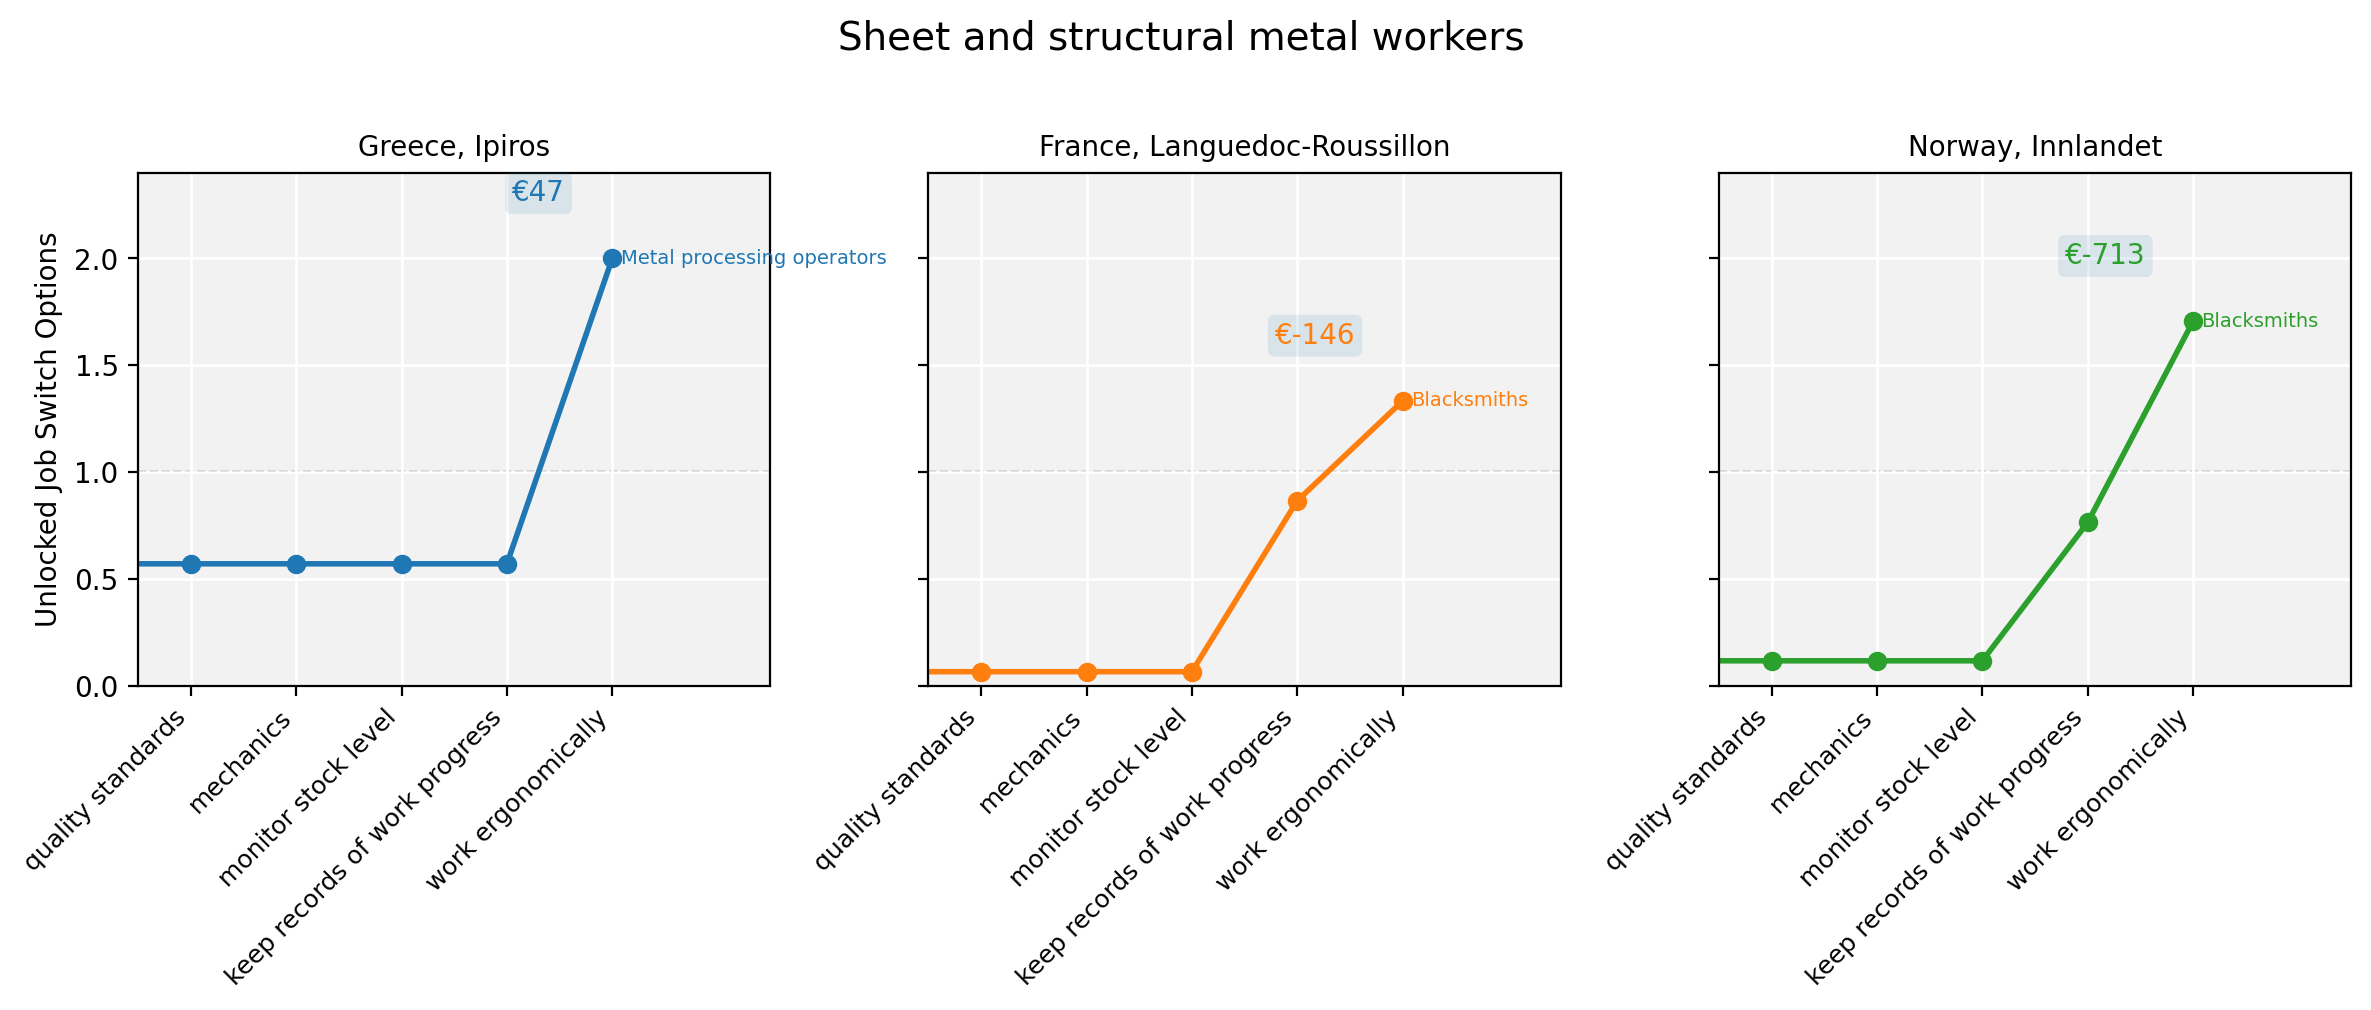

In [29]:
# ==========================================
# Journey cards (3 panels) — robust to missing unlocks
# ==========================================

#HARDCODED FOR ATRISK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

MODE = "reskill-optimal"
REG  = "regC"
POOL = "at_risk"
MAX_STEPS = 6

fixed_regions = [("EL","EL54"), ("FR","FRJ1"), ("NO","NO02")]
region_fullnames = {
    ("EL","EL54"): "Greece, Ipiros",
    ("FR","FRJ1"): "France, Languedoc-Roussillon",
    ("NO","NO02"): "Norway, Innlandet",
}
OCC_LABEL_OVERRIDE = None  # e.g. "sheet and structural metal workers"
earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]

def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"added_skill_label_step_{s}" for s in range(1, MAX_STEPS+1)] \
  + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

trans_all = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"]==MODE) &
    (df_tidy_long_transitions["regional_constraint"]==REG) &
    (df_tidy_long_transitions["job_pool"].isin(POOL_ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()
trans_all["n_transitions"]   = pd.to_numeric(trans_all["n_transitions"], errors="coerce")
trans_all["reskilling_step"] = pd.to_numeric(trans_all["reskilling_step"], errors="coerce").astype("Int64")

# pick occupation robustly (reuse function from the overlay cell if you’ve run it)
def pick_occ(df, fixed_regions, override=None, max_steps=6):
    occs = df["orig_ISCO08_3D_label"].dropna().unique().tolist()
    if override:
        cand = [o for o in occs if override.lower() in str(o).lower()]
        if cand: return cand[0]
    elig = df.loc[df["n_transitions"]>=1, ["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"]] \
             .groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID"], dropna=False)["reskilling_step"].min().reset_index()
    elig = elig[elig["reskilling_step"]<=max_steps]
    fr_set = set(fixed_regions)
    scores = []
    for occ, sub in elig.groupby("orig_ISCO08_3D_label"):
        covered = len(fr_set & set(sub[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1)))
        if covered>0:
            median_unlock = float(sub["reskilling_step"].median())
            scores.append((covered, -median_unlock, occ))
    if not scores:
        sub = df[df[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1).isin(fixed_regions)]
        return sub["orig_ISCO08_3D_label"].mode().iloc[0]
    scores.sort(reverse=True)
    return scores[0][2]

try:
    occ_source = occ_pick
except NameError:
    occ_source = pick_occ(trans_all, fixed_regions, override=OCC_LABEL_OVERRIDE, max_steps=MAX_STEPS)

trans = trans_all[trans_all["orig_ISCO08_3D_label"]==occ_source].copy()

# earnings attach
earn_col = None
if "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
        (df_tidy_long_earnings_merged["job_pool"].isin(POOL_ALIASES[POOL])),
        :
    ].copy()
    for c in earn_pref:
        if c in earn.columns:
            earn_col = c
            break
    if earn_col is not None:
        base_keys   = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"]
        merge_keys  = [k for k in base_keys if k in earn.columns]
        right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
        try:
            trans = trans.merge(right_slice, on=merge_keys, how="left", validate="m:1")
        except Exception:
            trans = trans.merge(right_slice, on=merge_keys, how="left")

# unlock table
gkeys = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","orig_ISCO08_3D_label"]
eligible = trans.loc[trans["n_transitions"] >= 1, gkeys + ["reskilling_step"]]
unlock = (eligible.groupby(gkeys, dropna=False)["reskilling_step"].min()
                 .reset_index(name="unlock_step"))
unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]

# per-card builder
def journey_for(cty, nuts, occ, unlock_step):
    sub = trans[(trans["COUNTRYW"]==cty)&(trans["NUTS_ID"]==nuts)&(trans["orig_ISCO08_3D_label"]==occ)].copy()
    if sub.empty: return None
    agg = (sub.groupby("reskilling_step", as_index=False)
              .agg(n_transitions=("n_transitions","median"),
                   **{f"added_skill_label_step_{s}": (f"added_skill_label_step_{s}", "first")
                      for s in range(1, MAX_STEPS+1) if f"added_skill_label_step_{s}" in sub.columns},
                   **({earn_col:(earn_col,"median")} if earn_col and earn_col in sub.columns else {})))
    agg = agg[agg["reskilling_step"] <= min(unlock_step, MAX_STEPS)]
    # pieces
    skills = {s: (agg[f"added_skill_label_step_{s}"].dropna().iloc[0]
                  if f"added_skill_label_step_{s}" in agg and agg[f"added_skill_label_step_{s}"].notna().any()
                  else "")
              for s in range(1, min(unlock_step, MAX_STEPS)+1)}
    tgt_col = f"transition_target_step_{unlock_step}"
    tgt = None
    if tgt_col in sub.columns and sub[tgt_col].notna().any():
        # highest-earning target at unlock if earnings exist, else mode
        sub_u = sub.loc[sub["reskilling_step"]==unlock_step, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])].dropna(subset=[tgt_col])
        if len(sub_u):
            if earn_col and earn_col in sub_u.columns:
                grp = sub_u.groupby(tgt_col, dropna=False)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else sub_u[tgt_col].mode().iloc[0]
            else:
                tgt = sub_u[tgt_col].mode().iloc[0]
    v_unlock = agg.loc[agg["reskilling_step"]==unlock_step, "n_transitions"]
    if v_unlock.empty: return None
    y_unlock = float(v_unlock.iloc[0])
    earn_val = None
    if earn_col and earn_col in agg.columns:
        vv = agg.loc[agg["reskilling_step"]==unlock_step, earn_col]
        if len(vv): earn_val = float(vv.iloc[0])
    return agg[["reskilling_step","n_transitions"]], y_unlock, skills, earn_val, tgt

# collect cards (skip missing gracefully)
cards = []
for r in fixed_regions:
    sub_u = unlock[(unlock["COUNTRYW"]==r[0]) & (unlock["NUTS_ID"]==r[1])]
    if sub_u.empty:
        print(f"[INFO] No unlock ≤ {MAX_STEPS} for {r} — skipping in cards.")
        continue
    ustep = int(sub_u["unlock_step"].iloc[0])
    out = journey_for(r[0], r[1], occ_source, ustep)
    if out is None:
        print(f"[INFO] Could not build journey for {r} — skipping.")
        continue
    dfj, y_unlock, skills, ev, tgt = out
    cards.append({"key": r, "name": region_fullnames[r], "df": dfj, "unlock": ustep,
                  "y_unlock": y_unlock, "skills": skills, "earn": ev, "tgt": tgt})

if not cards:
    raise ValueError("No valid journey cards found within MAX_STEPS for these regions.")

# plot cards
plt.style.use("default")
fig, axes = plt.subplots(ncols=len(cards), figsize=(4.0*len(cards), 4.5), sharey=True)
if not isinstance(axes, (list, np.ndarray)): axes = [axes]

# palette limited to present cards
palette_present = dict(zip([c["key"] for c in cards], plt.cm.tab10.colors[:len(cards)]))
y_max = max([c["y_unlock"] for c in cards] + [0.0])

for ax, card in zip(axes, cards):
    c = palette_present[card["key"]]
    d = card["df"]
    ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1)
    ax.grid(True, which="minor", color="white", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.plot(d["reskilling_step"], d["n_transitions"], marker="o", linewidth=2, color=c)
    ax.scatter([card["unlock"]], [card["y_unlock"]], color=c, s=30, zorder=5)
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)
    ax.set_xlim(0.5, MAX_STEPS + 0.5)
    ax.set_ylim(0, max(2.2, y_max + 0.4))
    steps = list(range(1, min(card["unlock"], MAX_STEPS) + 1))
    ticklabels = [card["skills"].get(s, "") for s in steps]
    ax.set_xticks(steps); ax.set_xticklabels(ticklabels, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("Unlocked Job Switch Options" if ax is axes[0] else "")
    ax.set_title(card["name"], fontsize=10)
    # annotations
    y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
    x_left = max(0.6, card["unlock"] - 0.45)
    if card["earn"] is not None and np.isfinite(card["earn"]):
        ax.text(x_left, card["y_unlock"] + 0.10*y_span, f"€{card['earn']:,.0f}",
                color=c, fontsize=10, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))
    if card["tgt"]:
        ax.text(card["unlock"] + 0.08, card["y_unlock"], short_target(card["tgt"]),
                color=c, fontsize=7, ha="left", va="center")

fig.suptitle(short_occ(occ_source), fontsize=14, y=1.02)
fig.tight_layout(); fig.subplots_adjust(bottom=0.28, top=0.85, wspace=0.25)

# save
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
fname = "journey_cards_{}_EL54_FRJ1_NO02.pdf".format(
    re.sub(r"[^A-Za-z0-9]+", "-", short_occ(occ_source)).strip("-").lower()
)
plt.savefig(os.path.join(out_dir, fname), bbox_inches="tight", format="pdf")
print("Saved:", os.path.join(out_dir, fname))

In [36]:
# =========================================================
# Pick ONE example region per occupation (no plotting)
#  - Scenario: shortage | Mode: reskill-optimal | Reg: regC
#  - Unlock step = first step where median(n_transitions) >= 1
#  - Country must NOT be in masked list (so earnings exist)
#  - Requires a valid €/worker at the unlock step
#  - Returns a tidy table with OCC → (COUNTRYW, NUTS_ID, unlock, target, €/worker)
# =========================================================
import pandas as pd
import numpy as np
import re

# --- config ---
OCC_LIST   = [
    "Machinery mechanics and repairers",
    "Handicraft workers",
    "Material-recording and transport clerks",
]
MODE       = "reskill-optimal"
REG        = "regC"
POOL       = "shortage"    # change to "at_risk" if needed
MAX_STEPS  = 30

# weighted €/worker preferred; fallback to unweighted
EARN_PREF  = ["earnings_delta_rel_w", "earnings_delta_rel"]

# countries with masked incomes — avoid
MASKED = {'IT','NL','DE','HU','AT','RO','PL','ES','LT','CY','BE','CZ','HR','IS','LV'}

ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}

# --- 1) slice long transitions for shortage/regC/mode ---
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

trans = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"] == MODE) &
    (df_tidy_long_transitions["regional_constraint"] == REG) &
    (df_tidy_long_transitions["job_pool"].astype(str).isin(ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

# clean numerics
trans["reskilling_step"] = pd.to_numeric(trans["reskilling_step"], errors="coerce").astype("Int64")
trans["n_transitions"]   = pd.to_numeric(trans["n_transitions"],   errors="coerce")

# --- 2) attach €/worker (weighted if available) ---
earn_col = None
if "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"] == MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"] == REG) &
        (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(ALIASES[POOL])),
        :
    ].copy()
    for c in EARN_PREF:
        if c in earn.columns:
            earn_col = c; break
    if earn_col is not None:
        mk = [k for k in ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"] if k in earn.columns]
        right = earn[mk + [earn_col]].drop_duplicates()
        # be robust to minor duplicates
        try:
            trans = trans.merge(right, on=mk, how="left", validate="m:1")
        except Exception:
            trans = trans.merge(right, on=mk, how="left")

# --- 3) helper to pick one (COUNTRYW, NUTS_ID) for a given occupation ---
def pick_region_for_occ(occ_label: str):
    sub = trans[trans["orig_ISCO08_3D_label"].astype(str) == occ_label].copy()
    if sub.empty:
        return None

    # regional median curve by step
    g = (sub.groupby(["COUNTRYW","NUTS_ID","reskilling_step"], dropna=True)["n_transitions"]
            .median().reset_index())

    # unlock per region = first step with median >= 1
    unlock = (g[g["n_transitions"] >= 1]
                .groupby(["COUNTRYW","NUTS_ID"], as_index=False)["reskilling_step"]
                .min()
                .rename(columns={"reskilling_step":"unlock_step"}))
    unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]
    if unlock.empty:
        return None

    # earnings at unlock (median €/worker) — require non-missing and non-masked country
    if earn_col is not None and earn_col in sub.columns:
        earn_at_unlock = (sub.groupby(["COUNTRYW","NUTS_ID","reskilling_step"], dropna=True)[earn_col]
                            .median().reset_index())
        cand = (unlock.merge(earn_at_unlock,
                             left_on=["COUNTRYW","NUTS_ID","unlock_step"],
                             right_on=["COUNTRYW","NUTS_ID","reskilling_step"],
                             how="left"))
        cand = cand.dropna(subset=[earn_col])
        cand = cand[~cand["COUNTRYW"].isin(MASKED)]
        if cand.empty:
            return None
        # choose the earliest unlock, tie-break by highest €/worker
        cand = cand.sort_values(by=["unlock_step", earn_col], ascending=[True, False])

        # target at unlock (highest-earning target label if multiple)
        row = cand.iloc[0]
        cty, nuts, ustep, earn_val = row["COUNTRYW"], row["NUTS_ID"], int(row["unlock_step"]), float(row[earn_col])

        tgt_col = f"transition_target_step_{ustep}"
        tgt = None
        if tgt_col in sub.columns:
            tmp = sub.loc[
                (sub["COUNTRYW"]==cty) & (sub["NUTS_ID"]==nuts) & (sub["reskilling_step"]==ustep),
                [tgt_col, earn_col]
            ].dropna(subset=[tgt_col])
            if not tmp.empty:
                grp = tmp.groupby(tgt_col)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else tmp[tgt_col].mode().iloc[0]

        return {
            "occupation": occ_label,
            "COUNTRYW": cty,
            "NUTS_ID": nuts,
            "unlock_step": ustep,
            "earnings_eur_per_worker_median": earn_val,
            "target_at_unlock": tgt
        }

    # if no earnings available at all, we can’t satisfy “valid wage tag” → skip
    return None

# --- 4) run for your three occupations and collect a tidy table ---
rows = []
for occ in OCC_LIST:
    res = pick_region_for_occ(occ)
    if res is not None:
        rows.append(res)
    else:
        rows.append({
            "occupation": occ,
            "COUNTRYW": None, "NUTS_ID": None,
            "unlock_step": None,
            "earnings_eur_per_worker_median": None,
            "target_at_unlock": None
        })

example_regions = pd.DataFrame(rows)
print(example_regions)

                                occupation COUNTRYW NUTS_ID  unlock_step  \
0        Machinery mechanics and repairers       FR    FRY4           24   
1                       Handicraft workers       FI    FI19           26   
2  Material-recording and transport clerks       CH    CH02           26   

   earnings_eur_per_worker_median  \
0                          623.01   
1                          474.44   
2                          466.97   

                                    target_at_unlock  
0                        Electrotechnology engineers  
1  Engineering professionals (excluding electrote...  
2                        Electrotechnology engineers  


Saved figure: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/journey_cards_shortage_top3_fixedregions.pdf


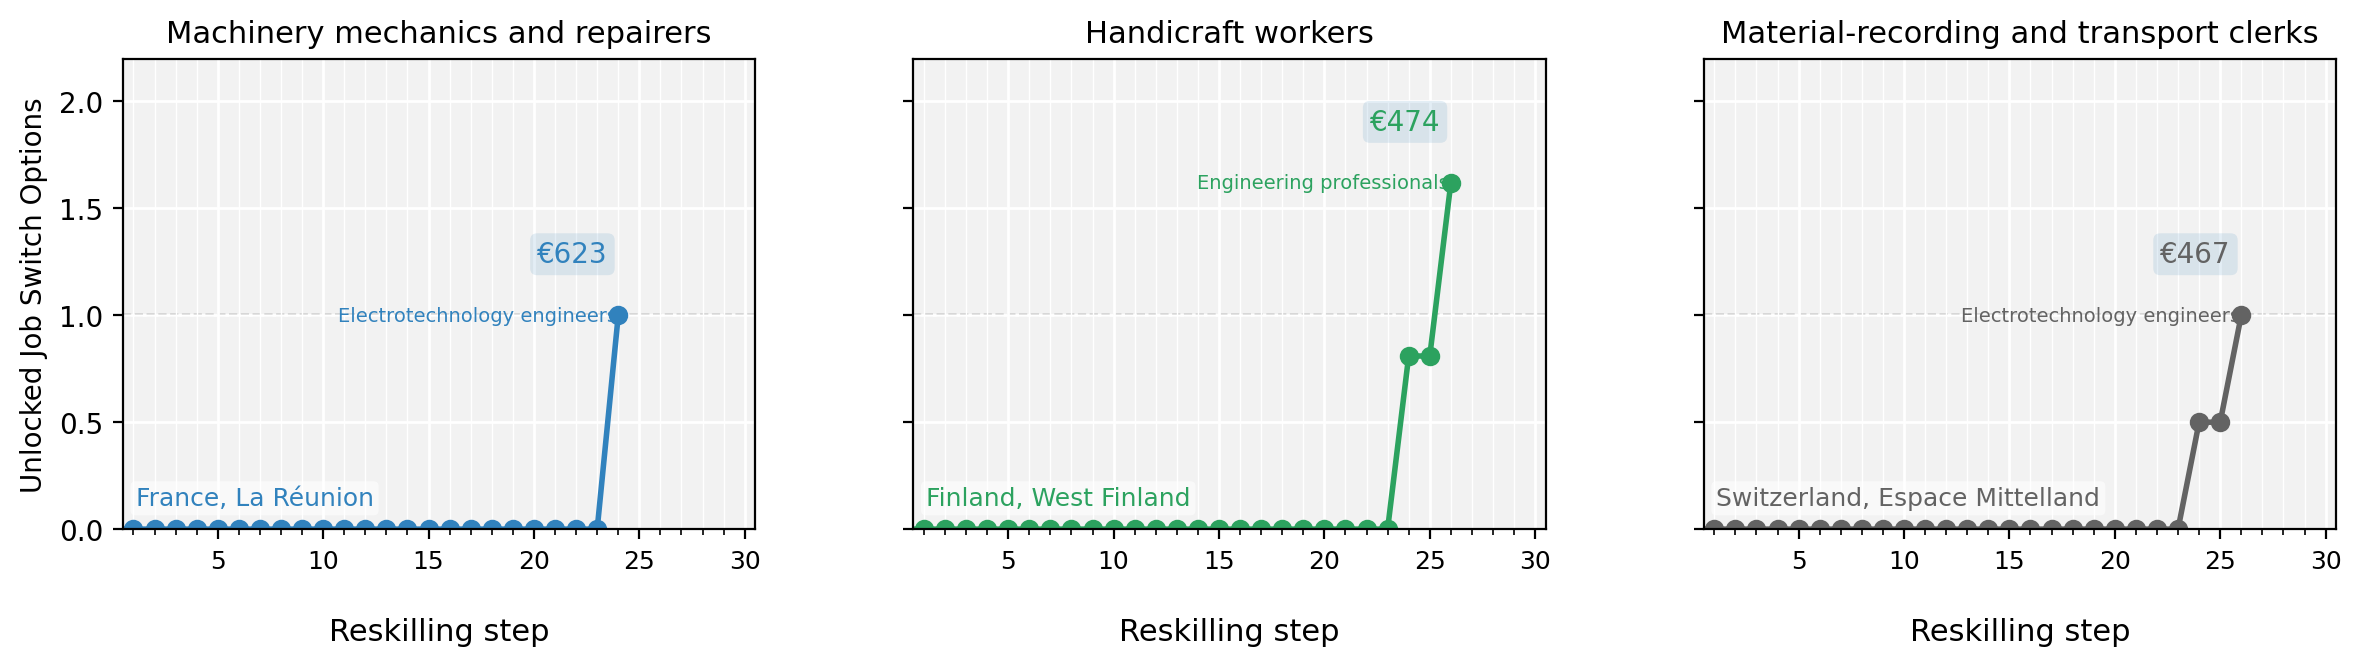

In [41]:
# ==========================================
# SHORTAGE (regC): 3 fixed region–occupation examples
# one region per panel; show steps 1–30 (labels only at 5s)
# target label LEFT of the dot; region name under each panel
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

# --- CONFIG ---
MODE       = "reskill-optimal"
REG        = "regC"
POOL       = "shortage"
MAX_STEPS  = 30

# your three chosen examples (from example_regions you printed)
EXAMPLES = [
    {"occ": "Machinery mechanics and repairers",            "COUNTRYW": "FR", "NUTS_ID": "FRY4"},
    {"occ": "Handicraft workers",                           "COUNTRYW": "FI", "NUTS_ID": "FI19"},
    {"occ": "Material-recording and transport clerks",      "COUNTRYW": "CH", "NUTS_ID": "CH02"},
]

# display region names
REGION_NAMES = {
    ("FR","FRY4"): "France, La Réunion",
    ("FI","FI19"): "Finland, West Finland",
    ("CH","CH02"): "Switzerland, Espace Mittelland",
}

# prefer weighted €/worker; fallback to unweighted if needed
earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

# helpers
def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

# ---------- slice transitions ----------
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

df = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"]==MODE) &
    (df_tidy_long_transitions["regional_constraint"]==REG) &
    (df_tidy_long_transitions["job_pool"].astype(str).isin(POOL_ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce").astype("Int64")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"],   errors="coerce")

# ---------- attach €/worker if available ----------
earn_col = None
if "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
        (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(POOL_ALIASES[POOL])),
        :
    ].copy()
    for c in earn_pref:
        if c in earn.columns:
            earn_col = c; break
    if earn_col is not None:
        merge_keys = [k for k in ["COUNTRYW","NUTS_ID","regional_constraint",
                                  "job_pool","reskilling_mode","reskilling_step"]
                      if k in earn.columns]
        right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
        try:
            df = df.merge(right_slice, on=merge_keys, how="left", validate="m:1")
        except Exception:
            df = df.merge(right_slice, on=merge_keys, how="left")

# ---------- build one panel from a specific region–occupation ----------
def build_panel(occ, cty, nuts):
    sub = df[(df["orig_ISCO08_3D_label"]==occ) & (df["COUNTRYW"]==cty) & (df["NUTS_ID"]==nuts)].copy()
    if sub.empty:
        return None

    # median per step for that region (robust to dup rows)
    ser = (sub.groupby("reskilling_step", dropna=True)["n_transitions"]
             .median().dropna().sort_index())

    # first unlock step (>=1) within bounds (1..MAX_STEPS)
    unlocked = ser[ser >= 1]
    if unlocked.empty:
        return None
    unlock = int(unlocked.index[0])
    if unlock > MAX_STEPS:
        return None

    # restrict series to [1..unlock]
    ser = ser[ser.index.astype(int) <= unlock]

    # earnings at unlock (median €/worker if available)
    earn_val = None
    if earn_col and earn_col in sub.columns:
        ev = sub.loc[sub["reskilling_step"]==unlock, earn_col].median()
        if pd.notna(ev): earn_val = float(ev)

    # target at unlock (highest €/worker if multiple; else modal)
    tgt = None
    tgt_col = f"transition_target_step_{unlock}"
    if tgt_col in sub.columns:
        tmp = sub.loc[sub["reskilling_step"]==unlock, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])]
        tmp = tmp.dropna(subset=[tgt_col])
        if not tmp.empty:
            if earn_col and earn_col in tmp.columns:
                grp = tmp.groupby(tgt_col)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else tmp[tgt_col].mode().iloc[0]
            else:
                tgt = tmp[tgt_col].mode().iloc[0]

    return {
        "occ": occ, "COUNTRYW": cty, "NUTS_ID": nuts,
        "series": ser, "unlock": unlock, "earn": earn_val, "tgt": tgt
    }

# ---------- assemble the three panels ----------
panels = []
for ex in EXAMPLES:
    p = build_panel(ex["occ"], ex["COUNTRYW"], ex["NUTS_ID"])
    if p is not None:
        panels.append(p)

if not panels:
    raise ValueError("No valid region–occupation panels found under current filters.")

# ---------- plot ----------
plt.style.use("default")
fig, axes = plt.subplots(ncols=len(panels), figsize=(12, 4.8), sharey=True)
if len(panels) == 1:
    axes = [axes]

colors = ["#3182bd", "#2ca25f", "#636363"]  # blue, green, grey
ymax = max([pp["series"].max() for pp in panels] + [1.2])

for ax, p, col in zip(axes, panels, colors):
    x = p["series"].index.values.astype(int)
    y = p["series"].values.astype(float)

    # panel style
    ax.set_facecolor("#f2f2f2")
    fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1)
    ax.grid(True, which="minor", color="white", linewidth=0.5)
    ax.set_axisbelow(True)

    # line up to unlock
    ax.plot(x, y, marker="o", linewidth=2, color=col)
    y_unlock = float(p["series"].loc[p["unlock"]])
    ax.scatter([p["unlock"]], [y_unlock], color=col, s=30, zorder=5)

    region_label = REGION_NAMES.get((p["COUNTRYW"], p["NUTS_ID"]), f"{p['COUNTRYW']}, {p['NUTS_ID']}")
    ax.text(
        0.02, 0.04, region_label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=9, color=col,
        clip_on=False,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none")
    )

    # guide at y=1 only
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)

    # x limits: show entire 1..MAX_STEPS, but the line itself stops at unlock
    ax.set_xlim(0.5, MAX_STEPS + 0.5)
    ax.set_ylim(0, max(2.2, ymax + 0.3))

    # show all steps as minor ticks, label only 5,10,15,20,25,30
    ax.set_xticks(range(1, MAX_STEPS + 1), minor=True)
    major_ticks = [5,10,15,20,25,30]
    ax.set_xticks(major_ticks, minor=False)
    ax.set_xticklabels(major_ticks, fontsize=9)

    # clean labels
    ax.set_xlabel("")
    ax.set_ylabel("Unlocked Job Switch Options" if ax is axes[0] else "")

    # per-panel x-axis label (instead of a shared supxlabel)
    ax.set_xlabel("Reskilling step", fontsize=11, labelpad=16)

    # panel title = source occupation
    ax.set_title(short_occ(p["occ"]), fontsize=11)

    # annotations:
    # (a) € above-left of dot
    y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
    if p["earn"] is not None and np.isfinite(p["earn"]):
        ax.text(max(0.6, p["unlock"] - 0.5), y_unlock + 0.10*y_span,
                f"€{p['earn']:,.0f}", color=col, fontsize=10,
                ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))

    # (b) target label to the LEFT of the dot (so it doesn’t run into the next panel)
    if p["tgt"]:
        ax.text(p["unlock"] - 0.08, y_unlock, short_target(p["tgt"]),
                color=col, fontsize=7, ha="right", va="center")

#fig.suptitle("Reskilling Journeys (shortage, regC) — three concrete region examples", fontsize=12, y=1.02)
fig.tight_layout()
fig.subplots_adjust(bottom=0.36, top=0.85, wspace=0.25)

# ---------- save ----------
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)

pdf_path = os.path.join(out_dir, "journey_cards_shortage_top3_fixedregions.pdf")
plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
print("Saved figure:", pdf_path)

In [ ]:
# Inspect top skills in reskill_optimal
# Attention: hard-coded for one scenario at a time [at_risk, shortage]

import os
import pandas as pd

# 1) Load the aggregated simulation output
base = os.path.join(
    useful_paths.figure_dir,
    "reskilling_simulation",
    "reskill-optimal_wage-opt_regC_2023",
)
sim = pd.read_pickle(os.path.join(base, "reskill-optimal_wage-opt_regC_2023.pkl"))

# 2) Pull out the “job pool”
df_cells = pd.concat(sim["at_risk"].values(), axis=0)

# 3) Identify all added‐skill‐label columns
skill_cols = [c for c in df_cells.columns if c.startswith("added_skill_label_step_")]

# 4) Melt into long form: one row per (cell, step, skill_label)
df_long = (
    df_cells
    .reset_index()[["orig_ISCO08_3D"] + skill_cols]
    .melt(
        id_vars="orig_ISCO08_3D",
        value_vars=skill_cols,
        var_name="step",
        value_name="skill_label"
    )
    .dropna(subset=["skill_label"])
)

# 5) Aggregate counts
agg = (
    df_long
    .groupby("skill_label")
    .agg(
        total_cells=("skill_label", "size"),              # how many cells received that skill
        unique_orig_ISCO=("orig_ISCO08_3D", "nunique")    # in how many source occupations
    )
    .reset_index()
)

# 6) Rank and pick top 10
agg["rank"] = agg["total_cells"].rank(method="first", ascending=False)
top10 = agg.sort_values("rank").head(30)[["rank", "skill_label", "total_cells", "unique_orig_ISCO"]]

# 7) Show results
print(top10.to_string(index=False))

# 8) Save to CSV
os.makedirs(useful_paths.table_dir, exist_ok=True)
csv_path = os.path.join(useful_paths.table_dir, "top10_added_skills_optimal_at_risk.csv")
top10.to_csv(csv_path, index=False)
print(f"\nTop 30 skills saved to {csv_path}")

In [33]:
# Inspect top skills in reskill_optimal
# Attention: hard-coded for one scenario at a time [at_risk, shortage]

import os
import pandas as pd

# 1) Load the aggregated simulation output
base = os.path.join(
    useful_paths.figure_dir,
    "reskilling_simulation",
    "reskill-optimal_wage-opt_regC_2023",
)
sim = pd.read_pickle(os.path.join(base, "reskill-optimal_wage-opt_regC_2023.pkl"))

# 2) Pull out the “job pool”
df_cells = pd.concat(sim["at_risk"].values(), axis=0)

# 3) Identify all added‐skill‐label columns
skill_cols = [c for c in df_cells.columns if c.startswith("added_skill_label_step_")]

# 4) Melt into long form: one row per (cell, step, skill_label)
df_long = (
    df_cells
    .reset_index()[["orig_ISCO08_3D"] + skill_cols]
    .melt(
        id_vars="orig_ISCO08_3D",
        value_vars=skill_cols,
        var_name="step",
        value_name="skill_label"
    )
    .dropna(subset=["skill_label"])
)

# 5) Aggregate counts
agg = (
    df_long
    .groupby("skill_label")
    .agg(
        total_cells=("skill_label", "size"),              # how many cells received that skill
        unique_orig_ISCO=("orig_ISCO08_3D", "nunique")    # in how many source occupations
    )
    .reset_index()
)

# 6) Rank and pick top 10
agg["rank"] = agg["total_cells"].rank(method="first", ascending=False)
top10 = agg.sort_values("rank").head(30)[["rank", "skill_label", "total_cells", "unique_orig_ISCO"]]

# 7) Show results
print(top10.to_string(index=False))

# 8) Save to CSV
os.makedirs(useful_paths.table_dir, exist_ok=True)
csv_path = os.path.join(useful_paths.table_dir, "top10_added_skills_optimal_at_risk.csv")
top10.to_csv(csv_path, index=False)
print(f"\nTop 30 skills saved to {csv_path}")

KeyError: 'at_risk'

#### 4. Boxplots for transition numbers

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_13751/2612741660.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureW

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/box_transitions_SH_steps_5_25_30.pdf


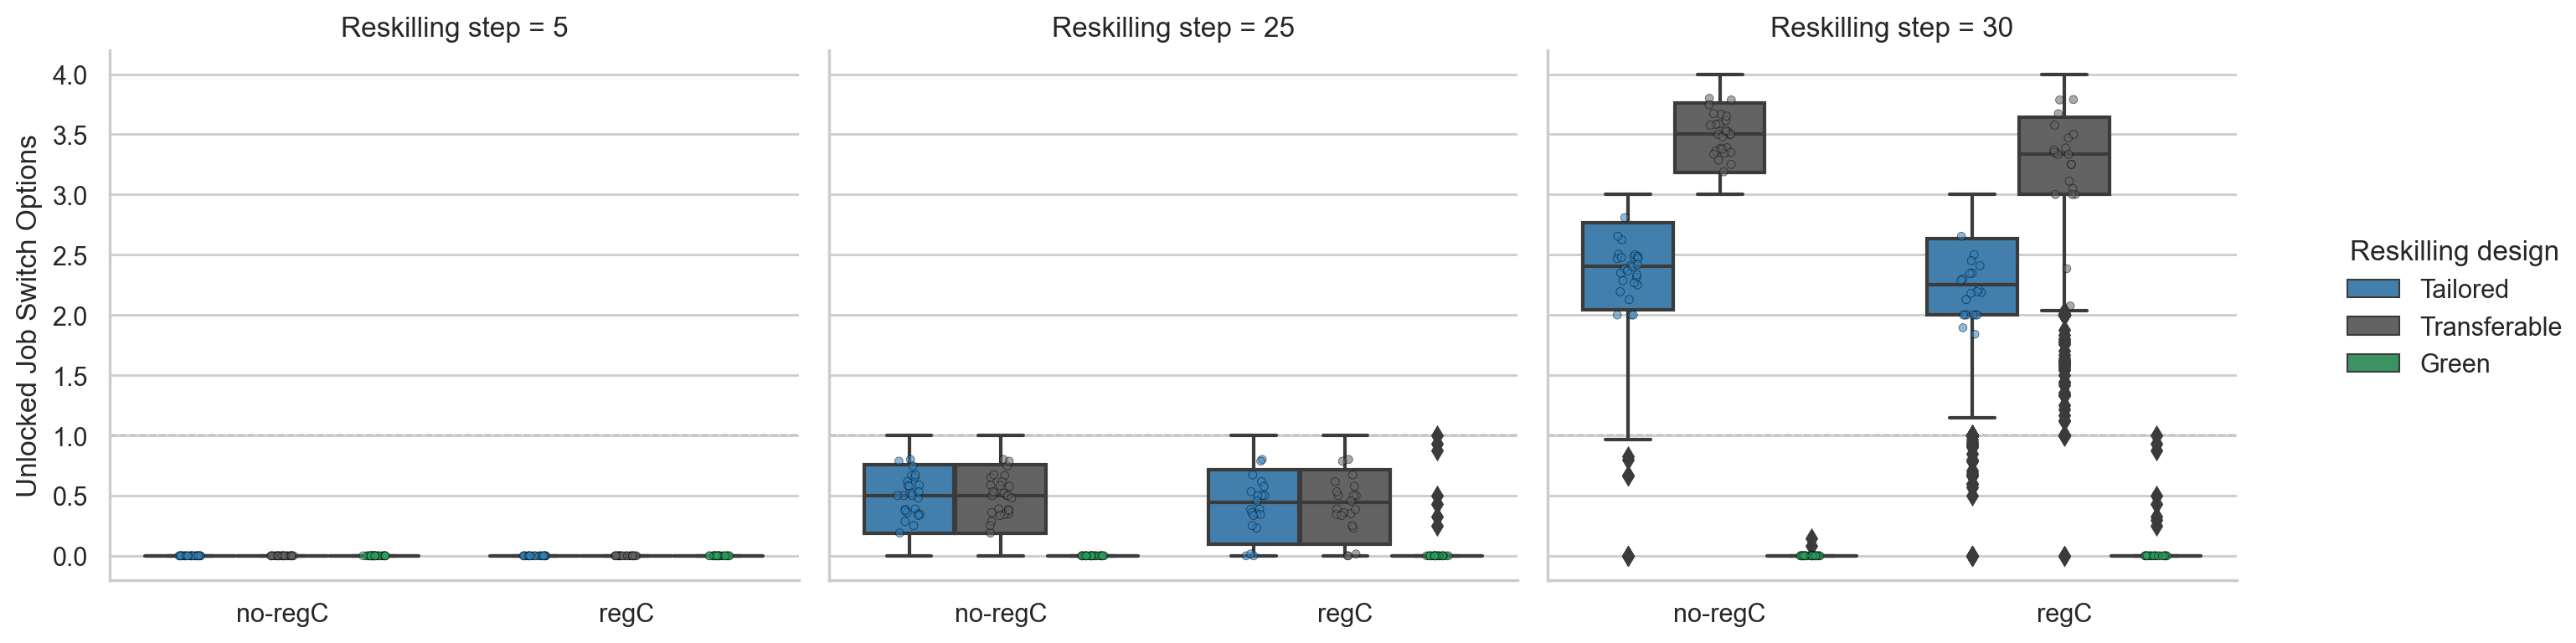

In [22]:
# ==========================================
# Boxplots of unlocked options by regC vs no-regC, per reskilling mode
# Faceted by step (e.g., 1,3,5); at_risk by default
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---- config
SCENARIO = "shortage"        # or "shortage"
STEPS    = [5, 25, 30]        # choose key steps to display
ORDER_X  = ["no-regC", "regC"]

# display labels for modes (same mapping you used before)
label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreWeight": "Transferable",
    "reskill-coreRanked": "Transferable",
    "reskill-green":    "Green" # shortage: "reskill-green":      "Green",
}

# palette (blue / green / grey family)
palette_dict_base = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Green":      "#2ca25f",  # green , shortage: "Green"
}

# scenario aliases
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}

# ---- build data slice from long transitions
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions"
]
data = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["job_pool"].isin(ALIASES[SCENARIO])) &
    (df_tidy_long_transitions["reskilling_step"].isin(STEPS)),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

# check
data["regional_constraint"] = pd.Categorical(
    data["regional_constraint"], categories=["no-regC","regC"], ordered=True
)

present = data["regional_constraint"].dropna().unique().tolist()
assert any(x in present for x in ["no-regC","regC"]), "No regC/no-regC rows found. Did the tidy rebuild finish?"

# clean numerics
data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce").astype(int)
data["n_transitions"]   = pd.to_numeric(data["n_transitions"], errors="coerce")
data = data.dropna(subset=["n_transitions"])

# map mode labels and restrict to present ones
data["mode_label"] = data["reskilling_mode"].map(label_map)
data = data.dropna(subset=["mode_label"])
hue_order = [m for m in ["Tailored","Transferable","Digital","Green"] if m in data["mode_label"].unique()]
palette_dict = {k: palette_dict_base[k] for k in hue_order}

# nicer facet titles
col_name = "Reskilling step"
data[col_name] = data["reskilling_step"].astype(int)

# ---- country-level medians for overlay dots (avoid overplot clutter)
df_country = (
    data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)
        ["n_transitions"].median()
)

# ---- plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=data,
    x="regional_constraint", y="n_transitions",
    hue="mode_label",
    col=col_name, col_order=sorted(data[col_name].unique()),
    order=ORDER_X, hue_order=hue_order,
    kind="box",
    dodge=True,
    showfliers=True,  # keep, but small markersize
    height=4, aspect=0.9,
    palette=palette_dict,
)

# style box fliers smaller
for ax in g.axes.flatten():
    for artist in ax.artists:
        pass  # seaborn handles styling; we’ll overlay points next

# overlay country medians as semi-transparent dots
for ax, step in zip(g.axes.flatten(), sorted(data[col_name].unique())):
    sub = df_country[df_country[col_name] == step]
    sns.stripplot(
        data=sub,
        x="regional_constraint", y="n_transitions",
        hue="mode_label",
        order=ORDER_X, hue_order=hue_order,
        dodge=True, size=3.5, linewidth=0.3,
        edgecolor="black", alpha=0.55,
        palette=palette_dict, ax=ax
    )
    # remove the duplicate legend generated by stripplot
    ax.legend_.remove() if ax.get_legend() else None

    # y=1 guide
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)

    # tidy labels
    ax.set_xlabel("")
    ax.set_ylabel("Unlocked Job Switch Options" if ax is g.axes.flatten()[0] else "")

# legend
try:
    g._legend.remove()
except Exception:
    pass

# add a fresh legend and move it
g.add_legend(title="Reskilling design")
leg = g._legend
if leg is not None:
    leg.set_bbox_to_anchor((1.02, 0.5))  # to the right, centered vertically
    # Matplotlib versions differ: prefer set_location(), else set_loc(), else fallback
    if hasattr(leg, "set_location"):
        leg.set_location("center left")
    elif hasattr(leg, "set_loc"):
        leg.set_loc("center left")
    else:
        leg._loc = 6  # center left (fallback; private attr)
    leg.set_frame_on(False)

# widen right margin so the legend isn't clipped
g.fig.subplots_adjust(right=0.82)

plt.tight_layout()

# ---- save PDF
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)

scenario_tag = "AR" if SCENARIO=="at_risk" else "SH"
steps_tag = "_".join(map(str, sorted(set(STEPS))))
outfile = os.path.join(out_dir, f"box_transitions_{scenario_tag}_steps_{steps_tag}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
print("Saved:", outfile)

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_13751/2422646271.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253:

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/box_earnings_per_worker_SH_steps_5_25_30_3modes.pdf


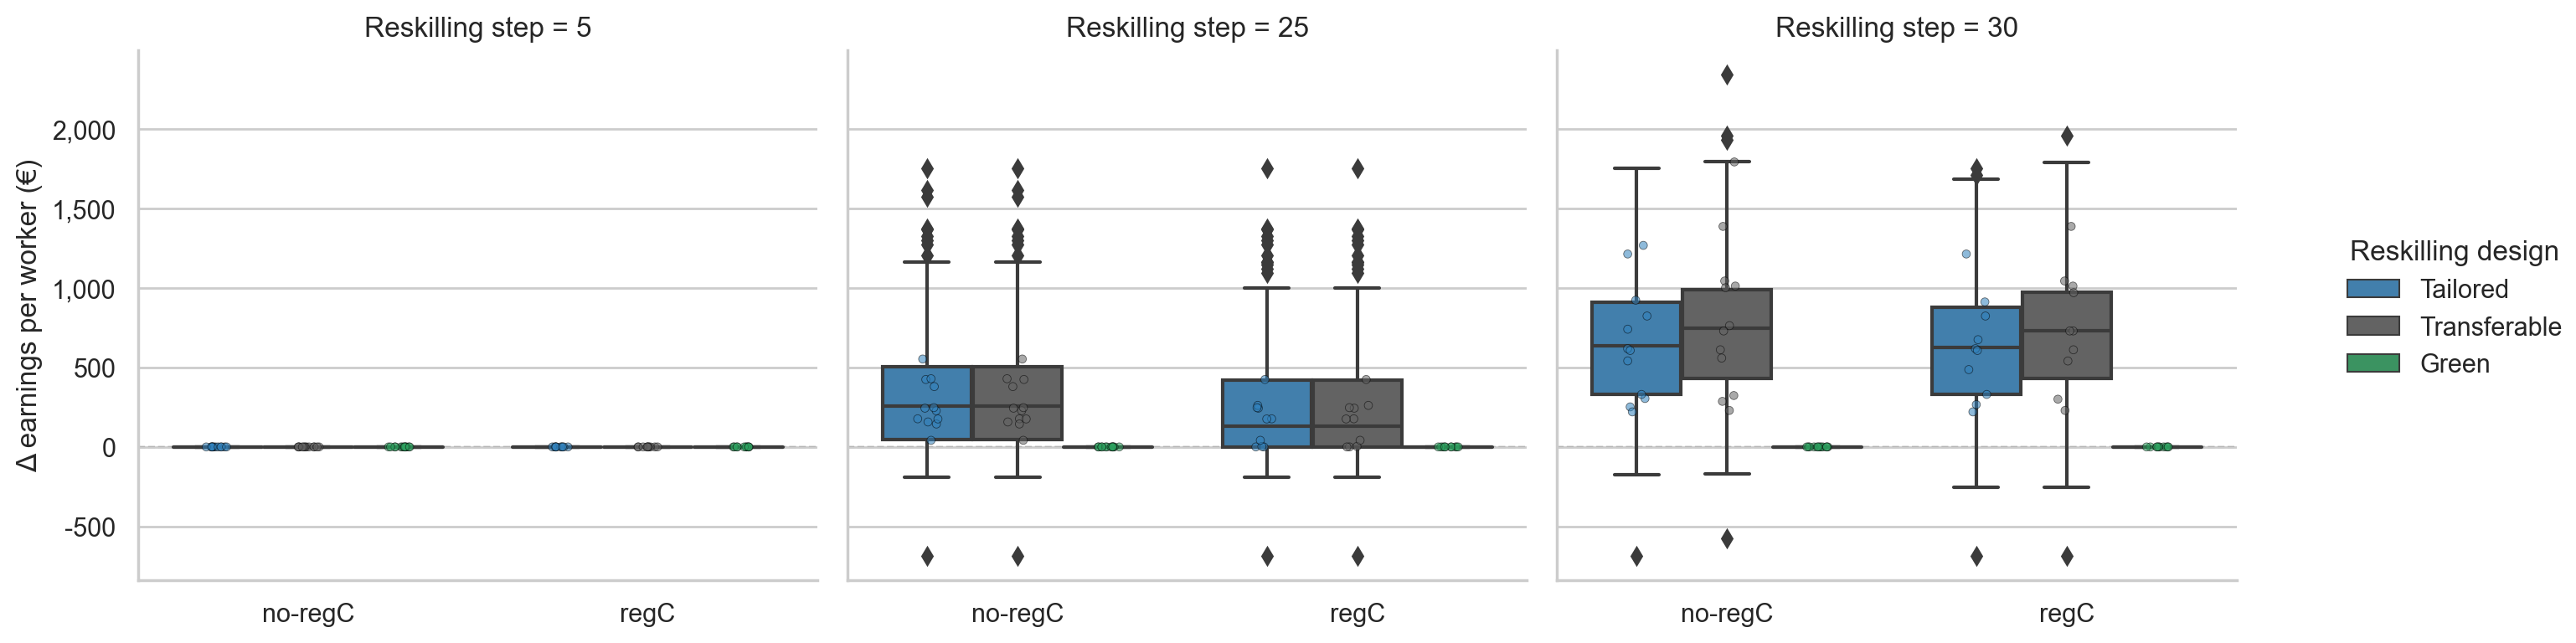

In [23]:
# ==========================================
# Boxplots of Δ earnings per worker (weighted) by regC vs no-regC
# Faceted by step; Tailored vs Transferable vs Digital/Green
# Runs right after your transitions boxplot
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# ---- config (reuse your choices)
SCENARIO = "shortage"        # or "shortage"
STEPS    = [5, 25, 30] # adapt when shortage/at_risk
ORDER_X  = ["no-regC", "regC"]

# Which three modes to show (Digital for at_risk; Green for shortage)
if SCENARIO == "shortage":
    MODES_WANTED = ["reskill-optimal", "reskill-coreRanked", "reskill-green"]
else:
    MODES_WANTED = ["reskill-optimal", "reskill-coreRanked", "reskill-digital"]

# Display labels & palette
label_map = {
    "reskill-optimal":     "Tailored",
    "reskill-coreRanked":  "Transferable",
    "reskill-coreWeight":  "Transferable",  # alias if present
    "reskill-digital":     "Digital",
    "reskill-green":       "Green",
}
palette_dict_base = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Digital":      "#2ca25f",  # green
    "Green":        "#2ca25f",  # green (same hue for shortage)
}

ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}

# ---- source frame (weighted €/worker preferred)
if "df_tidy_long_earnings_merged" not in globals():
    raise RuntimeError("df_tidy_long_earnings_merged not found. Run the tidy/melt prep first.")
y_candidates = ["earnings_delta_rel_w", "earnings_delta_rel"]  # weighted → fallback unweighted
y_col = next((c for c in y_candidates if c in df_tidy_long_earnings_merged.columns), None)
if y_col is None:
    raise RuntimeError("No per-worker earnings column found (earnings_delta_rel_w / earnings_delta_rel).")

# ---- slice data
need_cols = ["COUNTRYW","regional_constraint","job_pool","reskilling_mode","reskilling_step", y_col]
edata = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["job_pool"].isin(ALIASES[SCENARIO])) &
    (df_tidy_long_earnings_merged["reskilling_mode"].isin(MODES_WANTED)) &
    (df_tidy_long_earnings_merged["reskilling_step"].isin(STEPS)),
    [c for c in need_cols if c in df_tidy_long_earnings_merged.columns]
].copy()

# enforce x order and clean numerics
edata["regional_constraint"] = pd.Categorical(edata["regional_constraint"],
                                              categories=["no-regC","regC"], ordered=True)
edata["reskilling_step"] = pd.to_numeric(edata["reskilling_step"], errors="coerce").astype(int)
edata[y_col] = pd.to_numeric(edata[y_col], errors="coerce")
edata = edata.dropna(subset=[y_col])

# map display labels & palette (only those present)
edata["mode_label"] = edata["reskilling_mode"].map(label_map)
edata = edata.dropna(subset=["mode_label"])
hue_order = [m for m in ["Tailored","Transferable","Digital","Green"] if m in edata["mode_label"].unique()]
palette_dict = {k: palette_dict_base[k] for k in hue_order}

# facet title
col_name = "Reskilling step"
edata[col_name] = edata["reskilling_step"].astype(int)

# country-level medians for overlay dots
df_country = (
    edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
         .median()
)

# ---- plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=edata,
    x="regional_constraint", y=y_col,
    hue="mode_label",
    col=col_name, col_order=sorted(edata[col_name].unique()),
    order=[x for x in ORDER_X if x in edata["regional_constraint"].cat.categories],
    hue_order=hue_order,
    kind="box",
    dodge=True,
    showfliers=True,
    height=4, aspect=0.9,
    palette=palette_dict,
)

# overlay dots = country medians
for ax, step in zip(g.axes.flatten(), sorted(edata[col_name].unique())):
    sub = df_country[df_country[col_name] == step]
    if not sub.empty:
        sns.stripplot(
            data=sub,
            x="regional_constraint", y=y_col,
            hue="mode_label",
            order=[x for x in ORDER_X if x in edata["regional_constraint"].cat.categories],
            hue_order=hue_order,
            dodge=True, size=3.5, linewidth=0.3,
            edgecolor="black", alpha=0.55,
            palette=palette_dict, ax=ax
        )
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    ax.axhline(0, linestyle="--", color="black", linewidth=0.8, zorder=0)
    ax.set_xlabel("")
    ax.set_ylabel("Δ earnings per worker (€)" if ax is g.axes.flatten()[0] else "")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:,.0f}"))

# legend outside on the right (version-safe)
try:
    g._legend.remove()
except Exception:
    pass
g.add_legend(title="Reskilling design")
leg = g._legend
if leg is not None:
    leg.set_bbox_to_anchor((1.02, 0.5))
    if hasattr(leg, "set_location"):
        leg.set_location("center left")
    elif hasattr(leg, "set_loc"):
        leg.set_loc("center left")
    else:
        leg._loc = 6
    leg.set_frame_on(False)

g.fig.subplots_adjust(right=0.82)
plt.tight_layout()

# ---- save
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
scenario_tag = "AR" if SCENARIO=="at_risk" else "SH"
steps_tag   = "_".join(map(str, sorted(set(STEPS))))
mode_tag    = "digital" if SCENARIO=="at_risk" else "green"
outfile = os.path.join(out_dir, f"box_earnings_per_worker_{scenario_tag}_steps_{steps_tag}_3modes.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
print("Saved:", outfile)


#### (5. KDE plots)


In [108]:
# ==========================================
# Appendix: 2D KDE of (step, unlocked options)
# Facet by reskilling design; rows by regional_constraint if both present
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, re

# ---- detect scenario & step extent
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].astype(str).unique())
SCENARIO = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"
X_TARGET_MAX = 30 if SCENARIO == "shortage" else 20

# ---- filter base: scenario + available constraints
pool_filter = df_tidy_long_transitions["job_pool"].astype(str).isin(ALIASES[SCENARIO])
base = df_tidy_long_transitions.loc[pool_filter].copy()

# Which modes to show (Digital for at_risk; Green for shortage)
modes_wanted = ["reskill-optimal", "reskill-coreRanked",
                ("reskill-green" if SCENARIO == "shortage" else "reskill-digital")]
present_modes = set(base["reskilling_mode"].astype(str).unique())
modes_to_plot = [m for m in modes_wanted if m in present_modes]
if not modes_to_plot:
    raise ValueError(f"No expected reskilling modes found. Saw: {sorted(present_modes)}")

# Display labels & palette consistent with other figs
label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreRanked": "Transferable",
    "reskill-coreWeight": "Transferable",  # alias if older files
    "reskill-digital":    "Digital",
    "reskill-green":      "Green",
}
palette_map = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Digital":      "#2ca25f",  # green
    "Green":        "#2ca25f",  # green
}

df = base.loc[base["reskilling_mode"].isin(modes_to_plot)].copy()
df["mode_label"] = df["reskilling_mode"].map(label_map)

# numeric cleaning + tiny jitter on integer step to help KDE
df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"],   errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["reskilling_step","n_transitions"])

rng = np.random.default_rng(42)
df["step_jit"] = df["reskilling_step"] + rng.uniform(-0.15, 0.15, len(df))  # modest jitter

# axis ranges (shared across facets)
xmax = max(int(df["reskilling_step"].max()), X_TARGET_MAX)
lo, hi = df["n_transitions"].quantile([0.01, 0.99])
pad = 0.10 * max(1.0, abs(lo), abs(hi))
ymin, ymax = max(0.0, lo - pad), hi + pad

# constraints present?
present_constraints = df["regional_constraint"].dropna().astype(str).unique().tolist()
row_facet = "regional_constraint" if {"regC","no-regC"} & set(present_constraints) else None

# order columns by your design order
col_order = [label_map[m] for m in modes_to_plot]

# ---- build FacetGrid
facet_kws = dict(sharex=True, sharey=True, height=3.8, aspect=1.1)
if row_facet:
    g = sns.FacetGrid(df, row=row_facet, col="mode_label",
                      row_order=[x for x in ["no-regC","regC"] if x in present_constraints],
                      col_order=col_order, **facet_kws)
else:
    g = sns.FacetGrid(df, col="mode_label", col_order=col_order, **facet_kws)

# First pass (placeholder) so we can style per-axes
g.map_dataframe(sns.kdeplot, x="step_jit", y="n_transitions",
                fill=True, levels=8, thresh=0.03, bw_adjust=0.8, color="lightgrey")

# ---- style each facet with its own color and axes cosmetics
axes = g.axes.flat if hasattr(g.axes, "flat") else np.array([g.ax])
for ax in axes:
    # identify the facet's mode label from its title
    title = ax.get_title()
    # seaborn titles like: "mode_label = Tailored" or "regional_constraint = regC | mode_label = Tailored"
    m = re.search(r"mode_label\s*=\s*([^\|]+)$", title)
    label = m.group(1).strip() if m else col_order[0]
    color = palette_map.get(label, "#4c4c4c")

    # clear the generic collections and redraw with the right color
    ax.collections.clear()
    if row_facet:
        # get the row's constraint
        r = re.search(r"regional_constraint\s*=\s*([^\|]+)", title)
        rc = r.group(1).strip() if r else None
        sub = df[(df["mode_label"]==label) & ((df["regional_constraint"]==rc) if rc else True)]
    else:
        sub = df[df["mode_label"]==label]

    sns.kdeplot(
        data=sub,
        x="step_jit", y="n_transitions",
        fill=True, levels=8, thresh=0.03, bw_adjust=0.8,
        color=color, ax=ax
    )

    # panel styling to match your look
    ax.set_facecolor("white")
    ax.grid(True, which="major", axis="both", linewidth=0.8, color="0.92")
    ax.grid(True, which="minor", axis="both", linewidth=0.5, color="0.95")
    ax.axhline(1, linestyle="--", color="black", linewidth=0.7, zorder=0)

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)
    ax.set_yticks(np.arange(0, int(np.ceil(ymax)) + 1, 2), minor=False)
    ax.set_yticks(np.arange(0, int(np.ceil(ymax)) + 1, 1), minor=True)

    ax.set_xlabel("Reskilling step")
    ax.set_ylabel("Unlocked Job Switch Options")

# tidy titles
if row_facet:
    for ax in axes:
        ax.set_title(re.sub(r"^.*\|\s*mode_label\s*=\s*", "", ax.get_title()))
else:
    for ax in axes:
        ax.set_title(ax.get_title().replace("mode_label = ", ""))

sns.despine()
g.figure.subplots_adjust(top=0.86)
rc_text = "regC + no-regC" if row_facet else "regC only" if "regC" in present_constraints else "no-regC"
g.figure.suptitle(f"2D density of (step, unlocked options) — {SCENARIO.upper()}, {rc_text}", y=0.98)

# ---- save PDF
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
fname = f"{SCENARIO}_kde_transitions_by_mode_{'both' if row_facet else rc_text.replace(' ','_')}.pdf"
g.figure.savefig(os.path.join(out_dir, fname), bbox_inches="tight", format="pdf")
plt.close(g.figure)
print("Saved:", os.path.join(out_dir, fname))


/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_46555/3094953256.py:50: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["reskilling_step","n_transitions"])
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is depreca

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_kde_transitions_by_mode_both.pdf
